# 🦷 Dental X-Ray Detection: Faster R-CNN (Dataset 2 Only) — Kaggle

This notebook trains a single optimized Faster R-CNN model on **Dataset 2** (cavity, filling, impacted, implant).

### Optimization Stack
| Component | Technique |
|-----------|-----------|
| Backbone | ResNet-50-FPN v2 (COCO pretrained) with frozen BN |
| Augmentation | Heavy medical-grade: CLAHE, GridDistortion, MixUp |
| Class balancing | Weighted sampler |
| Training | Cosine-annealing LR + warm-up, AdamW with gradient clipping |
| Regularization | Label smoothing, Dropout on RoI head |
| Post-processing | Soft-NMS + confidence calibration |

### Dataset
| Dataset | Classes | Structure |
|---------|---------|----------|
| Dataset 2 | 4 (cavity, filling, impacted, implant) | Pre-split + data.yaml |

### Pipeline
1. Google Drive Mount  2. Deps  3. Config  4. Dataset Loaders  5. Analysis
6. Model Building  7. Training Engine  8. Train  9. Evaluation
10. Visualization  11. TTA  12. Export  13. Report  14. Summary


## 1. 🖥️ Kaggle Environment Setup


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 0: Kaggle Environment Setup
# Verifies input dataset paths and creates the working output directory.
# ─────────────────────────────────────────────────────────────────────────────
import os

KAGGLE_INPUT  = '/kaggle/input'
KAGGLE_OUTPUT = '/kaggle/working'

# ── List available input datasets ────────────────────────────────────────────
print('📂 Available Kaggle input datasets:')
if os.path.isdir(KAGGLE_INPUT):
    for ds in sorted(os.listdir(KAGGLE_INPUT)):
        ds_path = os.path.join(KAGGLE_INPUT, ds)
        n_files = sum(len(files) for _, _, files in os.walk(ds_path))
        print(f'   {ds}  ({n_files} files)')
else:
    print(f'   ⚠️  {KAGGLE_INPUT} not found – are you running on Kaggle?')

# ── Create output directory ───────────────────────────────────────────────────
os.makedirs(KAGGLE_OUTPUT, exist_ok=True)
print(f'\n✅ Output directory ready: {KAGGLE_OUTPUT}')
print('\n💡 Tip: Update dataset2_path in Cell 3 (Config) to match your')
print('        Kaggle dataset slug shown above if needed.')


📂 Available Kaggle input datasets:
   datasets  (1082 files)

✅ Output directory ready: /kaggle/working

💡 Tip: Update dataset2_path in Cell 3 (Config) to match your
        Kaggle dataset slug shown above if needed.


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# GPU Info — verify T4 x2 is active before training
# ─────────────────────────────────────────────────────────────────────────────
import subprocess

try:
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=index,name,memory.total,memory.free,temperature.gpu',
         '--format=csv,noheader,nounits'],
        capture_output=True, text=True, check=True
    )
    print('📊 nvidia-smi GPU Report:')
    print(f'  {"GPU":>4}  {"Name":<25}  {"Total VRAM":>10}  {"Free VRAM":>10}  {"Temp °C":>8}')
    print('  ' + '─' * 65)
    for line in result.stdout.strip().split('\n'):
        idx, name, total, free, temp = [x.strip() for x in line.split(',')]
        print(f'  {idx:>4}  {name:<25}  {int(total)/1024:>8.1f} GB  {int(free)/1024:>8.1f} GB  {temp:>7}°C')
except Exception as e:
    print(f'nvidia-smi not available: {e}')

import torch
print(f'\n🔦 torch.cuda.device_count() = {torch.cuda.device_count()}')
print(f'   CUDA available             = {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   Current device             = cuda:{torch.cuda.current_device()}')


📊 nvidia-smi GPU Report:
   GPU  Name                       Total VRAM   Free VRAM   Temp °C
  ─────────────────────────────────────────────────────────────────
     0  Tesla T4                       15.0 GB      11.3 GB       74°C
     1  Tesla T4                       15.0 GB      14.6 GB       36°C

🔦 torch.cuda.device_count() = 2
   CUDA available             = True
   Current device             = cuda:0


## 2. Environment Setup & Dependency Installation

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 1: Install dependencies
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip_install(
    'pycocotools', 'ensemble-boxes', 'albumentations>=1.3.0',
    'pyyaml', 'tqdm', 'matplotlib', 'seaborn', 'pandas',
    'scikit-learn', 'plotly', 'kaleido', 'jinja2',
    'timm',            # rich pretrained backbones
    'torchmetrics',    # clean mAP / precision / recall
)

print('✅ All dependencies installed.')

✅ All dependencies installed.


In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 2: Imports & global config
# ─────────────────────────────────────────────────────────────────────────────
import os, json, yaml, math, random, shutil, time, warnings, logging, copy
from pathlib import Path
from collections import defaultdict, Counter
from copy import deepcopy
from typing import Dict, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
import cv2
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision.models.detection import FasterRCNN, fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
import torchvision.transforms.functional as TF
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING)

# ─── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark    = True   # fastest conv for fixed input sizes
torch.backends.cudnn.deterministic = False  # allow non-det for max speed

# ─── Device — T4 x2 ─────────────────────────────────────────────────────────
NUM_GPUS = torch.cuda.device_count()

if NUM_GPUS > 0:
    DEVICE = torch.device('cuda')
    print(f'🚀 Found {NUM_GPUS} GPU(s):')
    for i in range(NUM_GPUS):
        props = torch.cuda.get_device_properties(i)
        print(f'   GPU {i}: {props.name} | VRAM: {props.total_memory/1e9:.1f} GB')
    if NUM_GPUS > 1:
        print(f'\n⚡ DataParallel enabled across {NUM_GPUS} GPUs')
        print(f'   Effective batch size = batch_size × {NUM_GPUS} GPUs')
else:
    DEVICE = torch.device('cpu')
    NUM_GPUS = 0
    print('⚠️  No GPU found — training will be very slow')

print(f'\nPyTorch {torch.__version__} | Torchvision {torchvision.__version__}')

🚀 Found 2 GPU(s):
   GPU 0: Tesla T4 | VRAM: 15.6 GB
   GPU 1: Tesla T4 | VRAM: 15.6 GB

⚡ DataParallel enabled across 2 GPUs
   Effective batch size = batch_size × 2 GPUs

PyTorch 2.10.0+cu128 | Torchvision 0.25.0+cu128


## 3. Configuration

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 3: Central config  ← edit here to tune training
# ─────────────────────────────────────────────────────────────────────────────
DEFAULT_CONFIG = {
    # ── Paths ──────────────────────────────────────────────────────────────
    'dataset2_path': '/kaggle/input/datasets/yousseforabi/dental-xray-coco',
    'output_dir':    '/kaggle/working/ds2_outputs',

    # ── Classes ────────────────────────────────────────────────────────────
    'classes_ds2': ['__background__', 'Cavity', 'Fillings', 'Impacted Tooth', 'Implant'],

    # ── Model / Backbone ───────────────────────────────────────────────────
    'backbone':      'resnet50',     # 'resnet50' | 'resnet101'
    'pretrained':    True,
    'freeze_bn':     True,
    'trainable_backbone_layers': 3,

    # ── Image / Anchors ────────────────────────────────────────────────────
    'image_size':    1024,
    'min_size':      800,
    'max_size':      1333,
    'anchor_sizes':   ((32,), (64,), (128,), (256,)),
    'anchor_ratios':  ((0.5, 1.0, 2.0),) * 4,
    'rpn_pre_nms_top_n_train':  3000,
    'rpn_post_nms_top_n_train': 2000,
    'rpn_pre_nms_top_n_test':   1500,
    'rpn_post_nms_top_n_test':  1000,
    'box_detections_per_img':   200,

    # ── Training ───────────────────────────────────────────────────────────
    'batch_size':    4,     # 2 per GPU × 2 GPUs (T4 x2)
    'num_workers':   8,     # 4 per GPU × 2 GPUs
    'num_epochs':    30,
    'warmup_epochs': 3,
    'lr':            5e-4,
    'backbone_lr_factor': 0.1,
    'weight_decay':  1e-4,
    'momentum':      0.9,
    'patience':      10,

    # ── Regularization ─────────────────────────────────────────────────────
    'label_smoothing': 0.05,
    'dropout_rate':    0.3,
    'mixup_alpha':     0.3,

    # ── Inference thresholds ───────────────────────────────────────────────
    'min_score':     0.25,
    'iou_threshold': 0.5,
    'soft_nms_sigma': 0.5,

    # ── TTA scales ─────────────────────────────────────────────────────────
    'tta_scales': [0.8, 1.0, 1.2],
}

CONFIG_FILE = 'config.yaml'
if os.path.exists(CONFIG_FILE):
    with open(CONFIG_FILE) as f:
        user_cfg = yaml.safe_load(f)
    DEFAULT_CONFIG.update(user_cfg)
    print(f'✅ Loaded overrides from {CONFIG_FILE}')

CFG = DEFAULT_CONFIG
os.makedirs(CFG['output_dir'], exist_ok=True)
with open(os.path.join(CFG['output_dir'], 'resolved_config.yaml'), 'w') as f:
    yaml.dump({k: v for k, v in CFG.items() if not isinstance(v, (list, tuple)) or len(str(v)) < 200}, f)

print('\n📁 Output directory:', CFG['output_dir'])
print(f"   image_size={CFG['image_size']}  batch={CFG['batch_size']}  epochs={CFG['num_epochs']}  lr={CFG['lr']}")



📁 Output directory: /kaggle/working/ds2_outputs
   image_size=1024  batch=4  epochs=30  lr=0.0005


## 4. Dataset Loaders

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 4: COCO label parser + Anchor Clustering (shared utilities)
# ─────────────────────────────────────────────────────────────────────────────
import json
from collections import defaultdict

def load_coco_annotations(json_path: Path, img_dir: Path) -> List[dict]:
    """Parse a COCO JSON file into a list of samples with absolute (x1,y1,x2,y2) boxes + class ids."""
    if not json_path.exists():
        print(f"⚠️ Warning: COCO JSON not found at {json_path}")
        return []
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    # Map image_id to list of annotations
    img_id_to_anns = defaultdict(list)
    for ann in data.get('annotations', []):
        x1, y1, w, h = ann['bbox']
        x2 = x1 + w
        y2 = y1 + h
        img_id_to_anns[ann['image_id']].append({
            'box': [x1, y1, x2, y2],
            'label': ann['category_id']  # 1-indexed category_id
        })
    
    samples = []
    for img in data.get('images', []):
        file_name = img['file_name']
        img_path = img_dir / file_name
        anns = img_id_to_anns[img['id']]
        boxes = []
        labels = []
        for ann in anns:
            boxes.append(ann['box'])
            labels.append(ann['label'])
        
        boxes = np.array(boxes, dtype=np.float32) if boxes else np.zeros((0, 4), dtype=np.float32)
        labels = np.array(labels, dtype=np.int64) if labels else np.zeros(0, dtype=np.int64)
        
        samples.append({
            'image_path': img_path,
            'boxes': boxes,
            'labels': labels,
            'width': img['width'],
            'height': img['height']
        })
    return samples

def calculate_kmeans_anchors(samples: List[dict], num_clusters: int = 4) -> Tuple[Tuple[int, ...], Tuple[float, ...]]:
    """Runs K-Means to find optimal anchor sizes and aspect ratios from COCO annotations."""
    from sklearn.cluster import KMeans
    boxes = []
    for sample in samples:
        for box in sample['boxes']:
            w = box[2] - box[0]
            h = box[3] - box[1]
            if w > 0 and h > 0:
                boxes.append([w, h])
    if not boxes:
        return (32, 64, 128, 256), (0.5, 1.0, 2.0)
    boxes = np.array(boxes)
    
    # 1. Optimal aspect ratios (w / h)
    ratios = boxes[:, 0] / boxes[:, 1]
    kmeans_ratios = KMeans(n_clusters=3, random_state=42, n_init='auto').fit(ratios.reshape(-1, 1))
    aspect_ratios = sorted([float(c[0]) for c in kmeans_ratios.cluster_centers_])
    aspect_ratios = [round(r, 2) for r in aspect_ratios]
    
    # 2. Optimal sizes (square root of area)
    areas = np.sqrt(boxes[:, 0] * boxes[:, 1])
    kmeans_sizes = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto').fit(areas.reshape(-1, 1))
    sizes = sorted([float(c[0]) for c in kmeans_sizes.cluster_centers_])
    sizes = [int(round(s)) for s in sizes]
    
    return tuple(sizes), tuple(aspect_ratios)

def parse_yolo_label(label_path: Path, img_w: int, img_h: int) -> Tuple[np.ndarray, np.ndarray]:
    return np.zeros((0, 4), dtype=np.float32), np.zeros(0, dtype=np.int64)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

def find_images(folder: Path) -> List[Path]:
    """Recursively find ALL images under folder, including sub-directories."""
    return sorted([p for p in folder.rglob('*')
                   if p.suffix.lower() in IMG_EXTS and p.is_file()])

def get_image_size(path: Path) -> Tuple[int, int]:
    """Returns (W, H) without loading full image."""
    with Image.open(path) as img:
        return img.size  # (W, H)

print('✅ COCO utilities + Anchor clustering ready.')


✅ COCO utilities + Anchor clustering ready.


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 5: DentalDataset + On-the-fly class-balanced augmentation (target 2k/class)
# ─────────────────────────────────────────────────────────────────────────────

# ── Count per-class samples in a split ───────────────────────────────────────
def count_samples_per_class(samples: List[dict]) -> Counter:
    """Count how many samples (images) contain each class."""
    cls_counts = Counter()
    for sample in samples:
        cls_ids = set(sample['labels'].tolist()) if len(sample['labels']) else set()
        for c in cls_ids:
            cls_counts[c] += 1
    return cls_counts

AUG_TARGET = 2000  # target samples per class for augmentation

class DentalDataset(Dataset):
    """
    Universal dental X-ray dataset with conditional on-the-fly augmentation (COCO format).
    Supports Multi-Scale Training via dynamic scale jittering.
    """
    def __init__(self, samples: List[dict],
                 transform=None, img_size: int = 800,
                 mixup_alpha: float = 0.0,
                 balance_to: int = AUG_TARGET,
                 legacy_normalization: bool = False,
                 is_train: bool = False):
        self.transform            = transform
        self.img_size             = img_size
        self.mixup_alpha          = mixup_alpha
        self.legacy_normalization = legacy_normalization
        self.is_train             = is_train

        if balance_to > 0 and is_train:
            self.samples, self.aug_flags = self._balance_samples(samples, balance_to)
        else:
            self.samples  = list(samples)
            self.aug_flags = [False] * len(self.samples)

    def _balance_samples(self, samples, target):
        # Build cls → list of sample indices
        cls_to_idxs: defaultdict = defaultdict(list)
        for i, sample in enumerate(samples):
            cls_ids = set(sample['labels'].tolist()) if len(sample['labels']) else {-1}
            for c in cls_ids:
                cls_to_idxs[c].append(i)

        new_samples = list(samples)
        aug_flags   = [False] * len(new_samples)

        for cls_id, idxs in cls_to_idxs.items():
            if cls_id < 0:
                continue
            have = len(idxs)
            if have >= target:
                continue
            need = target - have
            extra_idxs = [idxs[i % have] for i in range(need)]
            for ei in extra_idxs:
                new_samples.append(samples[ei])
                aug_flags.append(True)

        return new_samples, aug_flags

    def __len__(self):
        return len(self.samples)

    def _load_one(self, idx):
        sample = self.samples[idx]
        img_path = sample['image_path']
        img = cv2.imread(str(img_path))
        if img is None:
            img = np.zeros((self.img_size, self.img_size, 3), np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        boxes = sample['boxes'].copy()
        labels = sample['labels'].copy()
        
        # Ensure boxes are within image bounds
        h, w = img.shape[:2]
        if len(boxes):
            boxes[:, [0, 2]] = np.clip(boxes[:, [0, 2]], 0, w)
            boxes[:, [1, 3]] = np.clip(boxes[:, [1, 3]], 0, h)
            keep = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
            boxes = boxes[keep]
            labels = labels[keep]
            
        return img, boxes, labels

    def __getitem__(self, idx):
        img, boxes, labels = self._load_one(idx)

        # ── MixUp ────────────────────────────────────────────────────────
        if self.mixup_alpha > 0 and self.is_train and random.random() < 0.35:
            idx2 = random.randint(0, len(self.samples) - 1)
            img2, boxes2, labels2 = self._load_one(idx2)
            lam  = np.random.beta(self.mixup_alpha, self.mixup_alpha)
            img2 = cv2.resize(img2, (img.shape[1], img.shape[0]))
            img  = (lam * img.astype(np.float32) +
                    (1 - lam) * img2.astype(np.float32)).astype(np.uint8)
            if len(boxes2):
                boxes  = np.concatenate([boxes,  boxes2],  axis=0) if len(boxes) else boxes2
                labels = np.concatenate([labels, labels2], axis=0) if len(labels) else labels2

        # ── Dynamic Scale Jittering (Multi-Scale Training) ──────────────────
        target_size = self.img_size
        if self.is_train:
            target_size = int(random.choice([800, 896, 1024, 1152, 1280]))

        resize_tfm = A.Compose([
            A.LongestMaxSize(max_size=target_size),
            A.PadIfNeeded(target_size, target_size, border_mode=cv2.BORDER_CONSTANT, value=0),
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'], min_area=1, min_visibility=0.05))

        try:
            res = resize_tfm(image=img, bboxes=boxes.tolist() if len(boxes) else [], class_labels=labels.tolist() if len(labels) else [])
            img = res['image']
            boxes = np.array(res['bboxes'], dtype=np.float32)
            labels = np.array(res['class_labels'], dtype=np.int64)
        except Exception:
            pass

        # ── Augmentation transform ────────────────────────────────────────
        if self.transform:
            try:
                transformed = self.transform(
                    image=img,
                    bboxes=boxes.tolist() if len(boxes) else [],
                    class_labels=labels.tolist() if len(labels) else []
                )
                img    = transformed['image']
                boxes  = np.array(transformed['bboxes'],       dtype=np.float32)
                labels = np.array(transformed['class_labels'], dtype=np.int64)
            except Exception:
                t2 = self.transform(image=img, bboxes=[], class_labels=[])
                img = t2['image']

        # ── To tensor ────────────────────────────────────────────────────
        if isinstance(img, np.ndarray):
            if img.ndim == 2:
                img = np.stack([img, img, img], axis=-1)
            elif img.shape[2] == 1:
                img = np.repeat(img, 3, axis=2)
            elif img.shape[2] == 2:
                img = np.concatenate([img, img[:, :, :1]], axis=2)
            elif img.shape[2] > 3:
                img = img[:, :, :3]
            if self.legacy_normalization:
                img = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
            else:
                if img.max() > 10.0:
                    img = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
                else:
                    img = torch.from_numpy(img.transpose(2, 0, 1)).float()

        target = {
            'boxes':  torch.as_tensor(boxes,  dtype=torch.float32)
                      if len(boxes) > 0 else torch.zeros((0, 4), dtype=torch.float32),
            'labels': torch.as_tensor(labels, dtype=torch.int64)
                      if len(labels) > 0 else torch.zeros(0, dtype=torch.int64),
            'image_id': torch.tensor([idx]),
        }
        return img, target

def collate_fn(batch):
    return tuple(zip(*batch))

def build_weighted_sampler(samples: List[dict]) -> WeightedRandomSampler:
    class_counts: Counter = Counter()
    dominant = []
    for sample in samples:
        cls_ids = sample['labels'].tolist() if len(sample['labels']) else []
        dom = Counter(cls_ids).most_common(1)[0][0] if cls_ids else -1
        dominant.append(dom)
        class_counts[dom] += 1

    weights = [1.0 / max(class_counts[d], 1) for d in dominant]
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=False)

print('✅ DentalDataset with multi-scale + on-the-fly class balancing defined.')


✅ DentalDataset with multi-scale + on-the-fly class balancing defined.


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 6: Medical-grade augmentation pipelines (resizing managed by DentalDataset)
# ─────────────────────────────────────────────────────────────────────────────
IMG_SIZE = CFG['image_size']

TRAIN_TRANSFORM = A.Compose([
    # ── Geometric (safe for X-rays) ────────────────────────────────────────
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=10,
                       border_mode=cv2.BORDER_CONSTANT, p=0.6),
    A.RandomScale(scale_limit=0.2, p=0.4),
    A.GridDistortion(num_steps=5, distort_limit=0.05, p=0.2),   # lowered to prevent unnatural warping
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2), # slight panoramic simulation

    # ── Photometric (critical for X-ray quality variance) ─────────────────
    A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.35, p=0.7),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.6),      # enhances bone/tissue contrast
    A.Sharpen(alpha=(0.1, 0.4), lightness=(0.8, 1.2), p=0.3),
    A.ToGray(p=0.1, num_output_channels=3),  # keep 3ch — required by subsequent transforms & model
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),

    # ── Noise (simulate detector noise) ───────────────────────────────────
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.GaussNoise(var_limit=(15, 60), p=0.35),
    A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=0.2),

    # ── Coarse dropout (simulates artifacts / missing data) ───────────────
    A.CoarseDropout(max_holes=6, max_height=32, max_width=32, p=0.2),

    # ── Normalize ─────────────────────────────────────────────────────────
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
], bbox_params=A.BboxParams(
    format='pascal_voc', label_fields=['class_labels'],
    min_area=1, min_visibility=0.05   # keep almost all boxes after aug
))

VAL_TRANSFORM = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
], bbox_params=A.BboxParams(
    format='pascal_voc', label_fields=['class_labels'],
    min_area=1, min_visibility=0.1
))

# ── Multi-scale TTA transforms (one per scale) ─────────────────────────────
def make_tta_transform(scale: float):
    size = int(IMG_SIZE * scale)
    return A.Compose([
        A.LongestMaxSize(max_size=size),
        A.PadIfNeeded(size, size, border_mode=cv2.BORDER_CONSTANT, value=0),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ], bbox_params=A.BboxParams(
        format='pascal_voc', label_fields=['class_labels'],
        min_area=1, min_visibility=0.1
    ))

TTA_TRANSFORMS = {s: make_tta_transform(s) for s in CFG['tta_scales']}

print('✅ Augmentation pipelines ready.')
print(f'   Train transforms: {len(TRAIN_TRANSFORM.transforms)} steps')
print(f'   TTA scales: {list(TTA_TRANSFORMS.keys())}')


✅ Augmentation pipelines ready.
   Train transforms: 15 steps
   TTA scales: [0.8, 1.0, 1.2]


In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7: Dataset 2 loader (reads COCO annotations)
# ─────────────────────────────────────────────────────────────────────────────

# ── Helper: debug dataset root ───────────────────────────────────────────────
def _debug_root(root: Path, name: str):
    print(f"\n📂 {name} root: {root}")
    if not root.exists():
        print(f"   ❌ Path does NOT exist — check CFG paths!")
        return
    entries = sorted(root.iterdir())
    for e in entries[:20]:
        tag = "📁" if e.is_dir() else "📄"
        print(f"   {tag} {e.name}")
    if len(entries) > 20:
        print(f"   ... ({len(entries) - 20} more)")

# ── Dataset 2 loader (reads COCO format) ───────────────────────────────────
def load_dataset2(cfg: dict):
    root = Path(cfg['dataset2_path'])
    
    # Check if we should unzip locally
    if not root.exists():
        local_zip = Path("D:/Dataset/Dental X-ray.v1i.coco.zip")
        local_dir = Path("D:/Dataset/Dental X-ray.v1i.coco")
        if local_zip.exists():
            if not (local_dir / 'train' / '_annotations.coco.json').exists():
                print(f"📦 Extracting local zip {local_zip} to {local_dir}...")
                local_dir.mkdir(parents=True, exist_ok=True)
                import zipfile
                with zipfile.ZipFile(local_zip, 'r') as zip_ref:
                    from tqdm import tqdm
                    for member in tqdm(zip_ref.namelist(), desc="Extracting dataset"):
                        zip_ref.extract(member, local_dir)
                print("✅ Extraction complete.")
            root = local_dir
        else:
            print(f"⚠️ Warning: Dataset path {root} not found and no local zip fallback found.")
            
    print(f"📂 Dataset root path: {root}")
    _debug_root(root, 'Dataset2')
    
    def get_split_path(split_name):
        for candidate in [split_name, split_name.replace('val', 'valid')]:
            p = root / candidate
            if p.is_dir():
                return p
        raise FileNotFoundError(f"Cannot find split folder for '{split_name}' under {root}")

    train_dir = get_split_path('train')
    val_dir   = get_split_path('val')
    test_dir  = get_split_path('test')
    
    train_json = next(train_dir.glob('*coco.json'), train_dir / '_annotations.coco.json')
    val_json   = next(val_dir.glob('*coco.json'), val_dir / '_annotations.coco.json')
    test_json  = next(test_dir.glob('*coco.json'), test_dir / '_annotations.coco.json')
    
    train_samples = load_coco_annotations(train_json, train_dir)
    val_samples   = load_coco_annotations(val_json, val_dir)
    test_samples  = load_coco_annotations(test_json, test_dir)
    
    # Read classes dynamically from train JSON
    if train_json.exists():
        with open(train_json, 'r') as f:
            data = json.load(f)
        cats = data.get('categories', [])
        if cats:
            max_cat_id = max([c['id'] for c in cats])
            classes = ['__background__'] + [f'class_{i}' for i in range(1, max_cat_id + 1)]
            for c in cats:
                if c['id'] > 0:
                    classes[c['id']] = c['name']
            cfg['classes_ds2'] = classes
            print(f'  Using loaded COCO classes: {classes}')
            
    train = train_samples + val_samples
    print(f'Dataset2 (COCO) → train:{len(train_samples)}+val:{len(val_samples)}={len(train)} '
          f'(all used for training)  test:{len(test_samples)}')
    return train, val_samples, test_samples

print('✅ Dataset 2 (COCO) loader defined.')


✅ Dataset 2 (COCO) loader defined.


## 5. Data Analysis & Visualization

In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 8: Data analysis utilities
# ─────────────────────────────────────────────────────────────────────────────

def analyze_dataset(samples: List[dict],
                    class_names: List[str],
                    dataset_name: str = '') -> pd.DataFrame:
    """Return per-sample stats dataframe and print summary."""
    rows = []
    for sample in tqdm(samples, desc=f'Analysing {dataset_name}'):
        w, h = sample['width'], sample['height']
        boxes = sample['boxes']
        labels = sample['labels']
        for (x1, y1, x2, y2), cls_id in zip(boxes, labels):
            rows.append({
                'dataset':   dataset_name,
                'img_w':     w,
                'img_h':     h,
                'aspect':    round(w/h, 2),
                'cls_id':    cls_id,
                'cls_name':  class_names[cls_id] if cls_id < len(class_names) else f'cls{cls_id}',
                'box_w':     x2 - x1,
                'box_h':     y2 - y1,
                'box_area':  (x2-x1)*(y2-y1),
            })
    df = pd.DataFrame(rows)
    if df.empty:
        print(f'  [WARNING] No annotations found in {dataset_name}')
        return df

    print(f'\n=== {dataset_name} Analysis ===')
    print(f'  Images : {len(samples)}')
    print(f'  Objects: {len(df)}')
    print(f'  Image sizes (WxH): {int(df.img_w.mean())}x{int(df.img_h.mean())} avg')
    print(f'  BBox size (WxH):   {df.box_w.mean():.1f}x{df.box_h.mean():.1f} avg')
    print('  Class distribution:')
    print(df.cls_name.value_counts().to_string(header=False))
    return df

def plot_class_distribution(dfs: Dict[str, pd.DataFrame],
                             save_path: str = None):
    fig, axes = plt.subplots(1, len(dfs), figsize=(6*len(dfs), 5))
    if len(dfs) == 1:
        axes = [axes]
    for ax, (name, df) in zip(axes, dfs.items()):
        if df.empty:
            ax.set_title(f'{name} – no data')
            continue
        vc = df.cls_name.value_counts()
        vc.plot(kind='bar', ax=ax, colormap='tab10')
        ax.set_title(f'{name}', fontsize=13)
        ax.set_xlabel('Class'); ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
    plt.show()

def show_sample_images(samples: List[dict],
                       class_names: List[str],
                       n: int = 4,
                       title: str = ''):
    fig, axes = plt.subplots(1, min(n, len(samples)),
                             figsize=(5*min(n, len(samples)), 5))
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    chosen = random.sample(samples, min(n, len(samples)))
    for ax, sample in zip(axes, chosen):
        img_path = sample['image_path']
        img = np.array(Image.open(img_path).convert('RGB'))
        boxes = sample['boxes']
        labels = sample['labels']
        ax.imshow(img)
        for (x1, y1, x2, y2), cls_id in zip(boxes, labels):
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            lbl = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
            ax.text(x1, y1-4, lbl, color='red', fontsize=8,
                    bbox=dict(facecolor='white', alpha=0.5, pad=1))
        ax.axis('off')
        ax.set_title(img_path.name[:20], fontsize=8)
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

def plot_anchor_optimizations(df: pd.DataFrame, sizes: Tuple[int, ...], aspect_ratios: Tuple[float, ...], save_path: str = None):
    """Plots bounding box width/height distributions overlaid with KMeans optimal anchors."""
    if df.empty:
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('🔍 Anchor Box Optimization Analysis', fontsize=14, fontweight='bold')
    
    # 1. Scatter Plot of box widths vs heights
    ax = axes[0]
    ax.scatter(df['box_w'], df['box_h'], alpha=0.3, color='dodgerblue', label='GT Box Shapes')
    ax.set_xlabel('Width (pixels)')
    ax.set_ylabel('Height (pixels)')
    ax.set_title('Bounding Box Dimensions & Clustered Anchors')
    
    # Plot optimal sizes as square boxes at center of average aspect ratio
    mean_w_h = df['box_w'].mean() / df['box_h'].mean()
    for s in sizes:
        h_s = s / np.sqrt(mean_w_h)
        w_s = s * np.sqrt(mean_w_h)
        ax.plot([0, w_s], [0, h_s], color='crimson', linestyle='--', alpha=0.7)
        rect = patches.Rectangle((0, 0), w_s, h_s, linewidth=1.5, edgecolor='crimson', facecolor='none', alpha=0.9)
        ax.add_patch(rect)
    ax.plot([], [], color='crimson', label=f'KMeans Sizes: {sizes}', linewidth=1.5)
    ax.legend()
    
    # 2. Histogram of aspect ratios
    ax2 = axes[1]
    import seaborn as sns
    sns.histplot(df['aspect'], bins=30, kde=True, color='teal', ax=ax2, label='GT Aspect Ratios')
    ax2.set_xlabel('Aspect Ratio (Width / Height)')
    ax2.set_ylabel('Count')
    ax2.set_title('Aspect Ratio Distribution & Optimal Ratios')
    
    # Draw vertical lines at optimal aspect ratios
    colors = ['orange', 'red', 'purple']
    for idx, r in enumerate(aspect_ratios):
        ax2.axvline(r, color=colors[idx % len(colors)], linestyle='--', linewidth=2, label=f'Optimal: {r}')
    ax2.legend()
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"💾 Saved anchor plot → {save_path}")
    plt.show()

print('✅ Analysis & Anchor plotting utilities ready.')


✅ Analysis & Anchor plotting utilities ready.


In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 8b: 🔍 Path diagnostic for Dataset 2
# ─────────────────────────────────────────────────────────────────────────────
from pathlib import Path

root = Path(CFG['dataset2_path'])
print(f"{'='*60}")
print(f'  Dataset2  →  {CFG["dataset2_path"]}')
print(f"{'='*60}")
if not root.exists():
    print(f'  ❌ PATH DOES NOT EXIST')
    for parent in root.parents:
        if parent.exists():
            print(f'  ✅ Closest existing parent: {parent}')
            print(f'     Contents: {[d.name for d in parent.iterdir()]}')
            break
else:
    def _tree(p, prefix='', depth=0):
        if depth > 3:
            return
        items = sorted(p.iterdir())
        for i, item in enumerate(items):
            connector = '└── ' if i == len(items)-1 else '├── '
            marker = '📁' if item.is_dir() else '📄'
            n_files = ''
            if item.is_dir():
                try:
                    kids = list(item.iterdir())
                    n_files = f'  ({len(kids)} items)'
                except Exception:
                    pass
            print(f'  {prefix}{connector}{marker} {item.name}{n_files}')
            if item.is_dir():
                ext = '    ' if i == len(items)-1 else '│   '
                _tree(item, prefix + ext, depth + 1)
    _tree(root)

print('\n✅ Diagnostic complete.')


  Dataset2  →  /kaggle/input/datasets/yousseforabi/dental-xray-coco
  ├── 📄 README.dataset.txt
  ├── 📄 README.roboflow.txt
  ├── 📁 test  (108 items)
  │   ├── 📄 0002_jpg.rf.cec49076769bb88c1033a7a6f9c44122.jpg
  │   ├── 📄 0006_jpg.rf.f76d9a750c3ca0fb732dcdfc763282e3.jpg
  │   ├── 📄 0010_jpg.rf.fc353845a6614b0ad4a0b407f3b5bbdf.jpg
  │   ├── 📄 0017_jpg.rf.17a2370fb6321030f9531b2f19f2ac41.jpg
  │   ├── 📄 0024_jpg.rf.e794d266b6f604461d78c92f65062b41.jpg
  │   ├── 📄 0027_jpg.rf.ab8c1ebedec7c35309c76334720305b6.jpg
  │   ├── 📄 0028_jpg.rf.56f7d7af112232e407a6f3cc46f79a80.jpg
  │   ├── 📄 0033_jpg.rf.5ec3b2cf7ecbe2b5d7f7962b705c82fc.jpg
  │   ├── 📄 0036_jpg.rf.2b3b7d5d0e62571de17de74551f6424d.jpg
  │   ├── 📄 0046_jpg.rf.17a0cfaf922899a286d3f650fdd5810a.jpg
  │   ├── 📄 0047_jpg.rf.39fcc3f73c9b8f15871f496b4f9777a8.jpg
  │   ├── 📄 0057_jpg.rf.ba95ff24283953b488e5e459c479f929.jpg
  │   ├── 📄 0057_jpg.rf.bb30ceb63a4ba18177afe623fac71f6b.jpg
  │   ├── 📄 0059_jpg.rf.dfef85935241820a0d7384f83caf664d.j

Loading dataset...
📂 Dataset root path: /kaggle/input/datasets/yousseforabi/dental-xray-coco

📂 Dataset2 root: /kaggle/input/datasets/yousseforabi/dental-xray-coco
   📄 README.dataset.txt
   📄 README.roboflow.txt
   📁 test
   📁 train
   📁 valid
  Using loaded COCO classes: ['__background__', 'Cavity', 'Fillings', 'Impacted Tooth', 'Implant']
Dataset2 (COCO) → train:753+val:215=968 (all used for training)  test:107


Analysing Dataset2:   0%|          | 0/1290 [00:00<?, ?it/s]


=== Dataset2 Analysis ===
  Images : 1290
  Objects: 9684
  Image sizes (WxH): 640x640 avg
  BBox size (WxH):   30.2x112.5 avg
  Class distribution:
Fillings          6313
Implant           2155
Cavity             720
Impacted Tooth     496


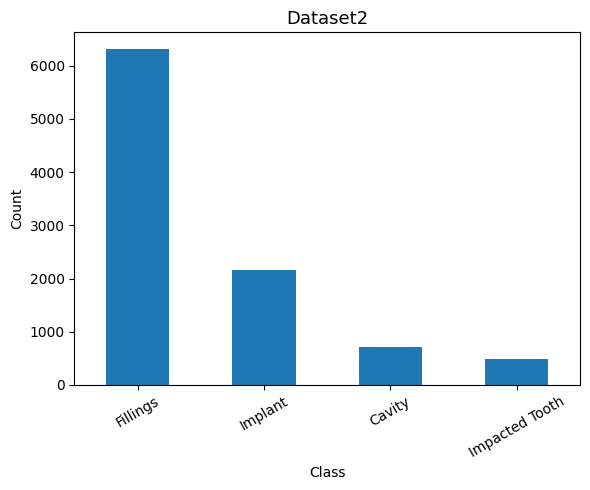


Calculating optimal anchors via KMeans...
Optimal sizes: (38, 52, 64, 78)
Optimal aspect ratios: (0.19, 0.31, 0.48)
💾 Saved anchor plot → /kaggle/working/ds2_outputs/plots/anchor_optimizations.png


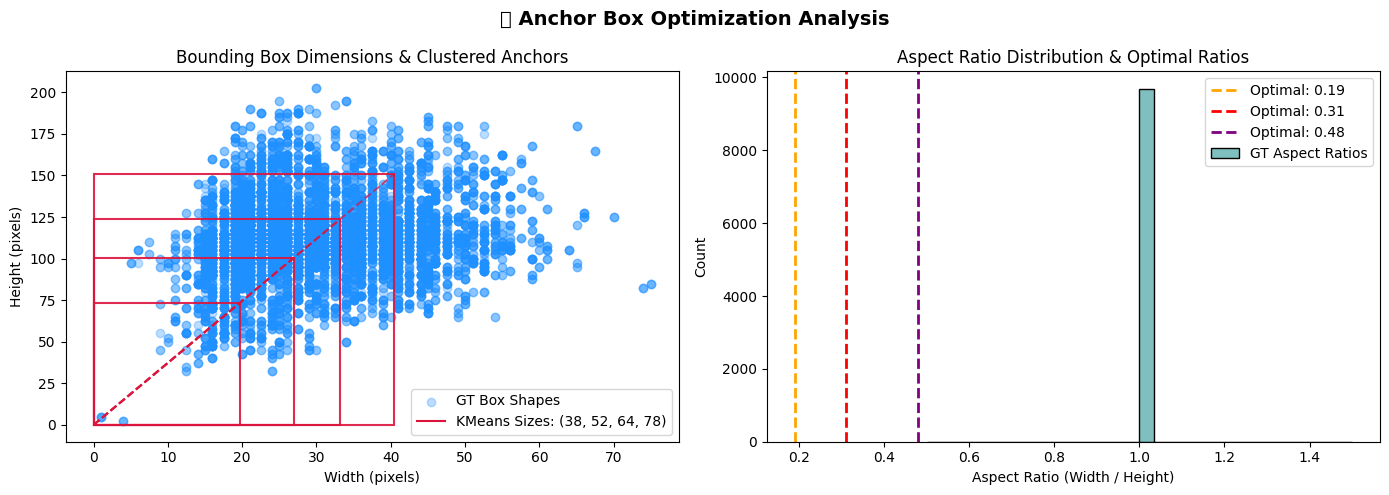

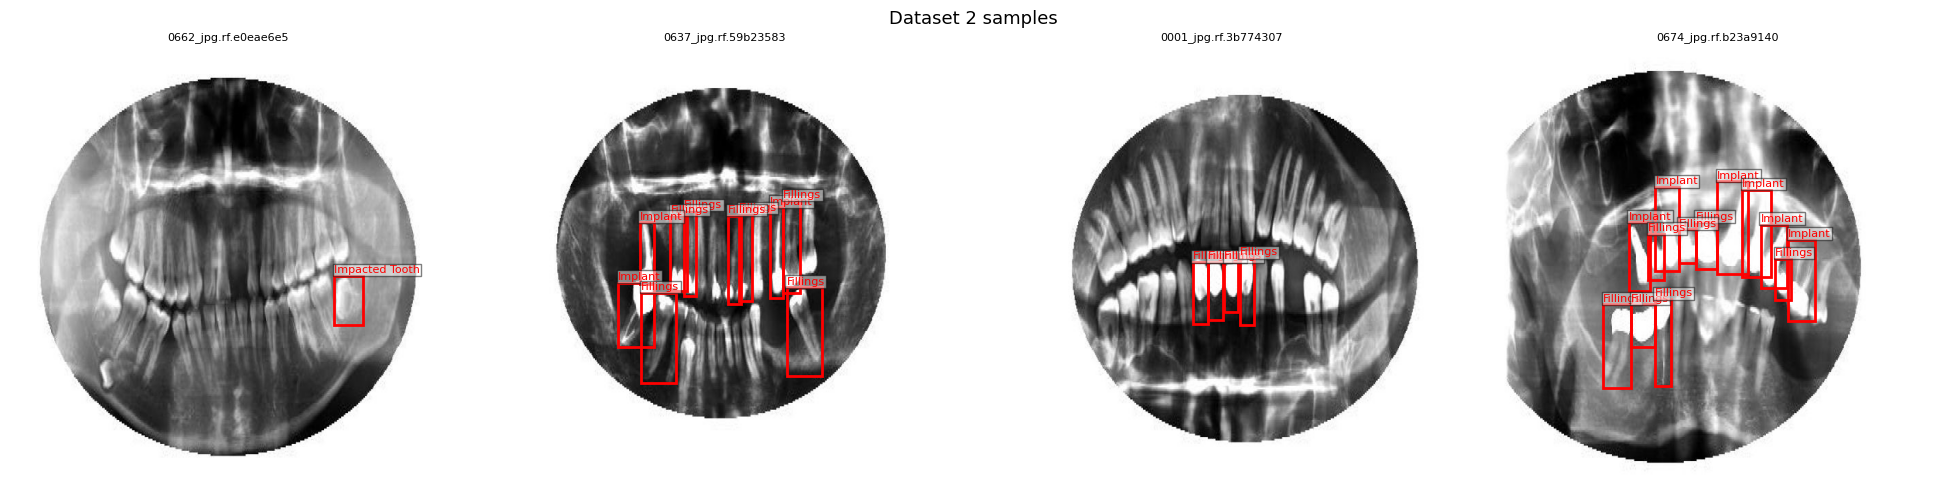

In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 9: Load and analyse Dataset 2
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(f"{CFG['output_dir']}/plots", exist_ok=True)

print('Loading dataset...')
ds2_train, ds2_val, ds2_test = load_dataset2(CFG)

df2 = analyze_dataset(ds2_train + ds2_val + ds2_test, CFG['classes_ds2'], 'Dataset2')

plot_class_distribution(
    {'Dataset2': df2},
    save_path=f"{CFG['output_dir']}/plots/class_distribution.png"
)

# Compute and plot KMeans optimal anchors on the dataset
if ds2_train:
    print("\nCalculating optimal anchors via KMeans...")
    opt_sizes, opt_ratios = calculate_kmeans_anchors(ds2_train, num_clusters=4)
    print(f"Optimal sizes: {opt_sizes}")
    print(f"Optimal aspect ratios: {opt_ratios}")

    plot_anchor_optimizations(
        df2, opt_sizes, opt_ratios,
        save_path=f"{CFG['output_dir']}/plots/anchor_optimizations.png"
    )

if ds2_train:
    show_sample_images(ds2_train, CFG['classes_ds2'], n=4, title='Dataset 2 samples')


### 📊 Class Balance: Before vs After Augmentation


💾 Saved → /kaggle/working/ds2_outputs/plots/class_balance_before_after.png


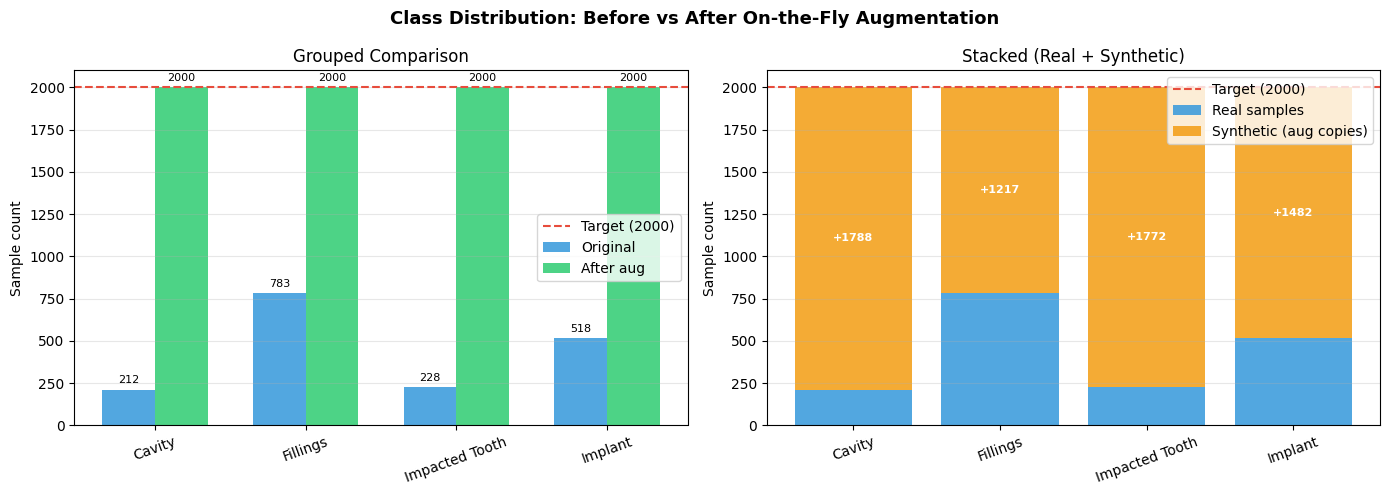


Class          Before    After    Added   Augmented?
────────────────────────────────────────────────────
Cavity            212     2000     1788        ✅ yes
Fillings          783     2000     1217        ✅ yes
Impacted Tooth      228     2000     1772        ✅ yes
Implant           518     2000     1482        ✅ yes

  AUG_TARGET = 2000 samples/class
  Total real samples : 1741
  Total after aug    : 8000


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 9b: 📊 Class Balance Before vs After Augmentation
# Shows per-class sample counts before and after on-the-fly balancing.
# ─────────────────────────────────────────────────────────────────────────────

def compare_class_balance(samples_before: list,
                           class_names: List[str],
                           aug_target: int = AUG_TARGET,
                           save_path: str = None):
    """
    Visualise per-class sample count before augmentation vs after on-the-fly
    balancing to aug_target. Classes already at/above aug_target are shown
    without a change bar.
    """
    # ── Count real samples per class ────────────────────────────────────────
    cls_image_counts = defaultdict(set)  # cls_id -> set of image paths
    is_coco = len(samples_before) > 0 and isinstance(samples_before[0], dict)
    
    if is_coco:
        for sample in samples_before:
            img_path = sample['image_path']
            cls_ids = sample.get('labels', [])
            for c in cls_ids:
                cls_image_counts[c].add(img_path)
    else:
        for item in samples_before:
            img_path, lbl_path = item
            if lbl_path.exists():
                cls_ids = {int(l.split()[0]) for l in open(lbl_path) if l.strip()}
            else:
                cls_ids = set()
            for c in cls_ids:
                cls_image_counts[c].add(img_path)

    # Build before / after counts
    real_classes = sorted(cls_image_counts.keys())
    if is_coco:
        names_plot = [class_names[c] if c < len(class_names) else f'cls{c}'
                      for c in real_classes]
    else:
        names_plot = [class_names[c+1] if (c+1) < len(class_names) else f'cls{c}'
                      for c in real_classes]
    before_counts = [len(cls_image_counts[c]) for c in real_classes]
    after_counts  = [max(cnt, aug_target) for cnt in before_counts]
    aug_added     = [a - b for a, b in zip(after_counts, before_counts)]

    # ── Figure: side-by-side & stacked ──────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Class Distribution: Before vs After On-the-Fly Augmentation',
                 fontsize=13, fontweight='bold')

    x = np.arange(len(names_plot))
    w = 0.35

    # Left: grouped bar
    ax = axes[0]
    bars_b = ax.bar(x - w/2, before_counts, w, label='Original',  color='#3498db', alpha=0.85)
    bars_a = ax.bar(x + w/2, after_counts,  w, label='After aug', color='#2ecc71', alpha=0.85)
    ax.axhline(aug_target, color='#e74c3c', linestyle='--', linewidth=1.5,
               label=f'Target ({aug_target})')
    ax.bar_label(bars_b, padding=3, fontsize=8)
    ax.bar_label(bars_a, padding=3, fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(names_plot, rotation=20)
    ax.set_ylabel('Sample count'); ax.set_title('Grouped Comparison')
    ax.legend(); ax.grid(axis='y', alpha=0.3)

    # Right: stacked bar showing "real" + "synthetic"
    ax2 = axes[1]
    bars_real = ax2.bar(x, before_counts, color='#3498db', alpha=0.85, label='Real samples')
    bars_aug  = ax2.bar(x, aug_added,  bottom=before_counts,
                        color='#f39c12', alpha=0.85, label='Synthetic (aug copies)')
    ax2.axhline(aug_target, color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'Target ({aug_target})')
    ax2.set_xticks(x); ax2.set_xticklabels(names_plot, rotation=20)
    ax2.set_ylabel('Sample count'); ax2.set_title('Stacked (Real + Synthetic)')
    ax2.legend(); ax2.grid(axis='y', alpha=0.3)

    for i, (b, a_add) in enumerate(zip(before_counts, aug_added)):
        if a_add > 0:
            ax2.text(i, b + a_add/2, f'+{a_add}', ha='center', va='center',
                     fontsize=8, color='white', fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Saved → {save_path}')
    plt.show()

    # Print table
    print(f'\n{"Class":<12} {"Before":>8} {"After":>8} {"Added":>8} {"Augmented?":>12}')
    print('─' * 52)
    for name, b, a, add in zip(names_plot, before_counts, after_counts, aug_added):
        aug_flag = '✅ yes' if add > 0 else '⚪ no (≥target)'
        print(f'{name:<12} {b:>8} {a:>8} {add:>8} {aug_flag:>12}')
    print(f'\n  AUG_TARGET = {aug_target} samples/class')
    print(f'  Total real samples : {sum(before_counts)}')
    print(f'  Total after aug    : {sum(after_counts)}')

compare_class_balance(
    ds2_train,
    CFG['classes_ds2'],
    aug_target=AUG_TARGET,
    save_path=f"{CFG['output_dir']}/plots/class_balance_before_after.png"
)


## 6. Model Building

In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 10: Optimized Faster R-CNN builder (CIoU + Anchors support)
# ─────────────────────────────────────────────────────────────────────────────
from typing import Optional, List, Dict, Tuple
from torchvision.ops import complete_box_iou_loss

# Custom RoIHeads forward to support Complete IoU (CIoU) Box Regression Loss
def custom_roi_heads_forward(
    self,
    features: Dict[str, torch.Tensor],
    proposals: List[torch.Tensor],
    image_shapes: List[Tuple[int, int]],
    targets: Optional[List[Dict[str, torch.Tensor]]] = None,
) -> Tuple[List[Dict[str, torch.Tensor]], Dict[str, torch.Tensor]]:
    if targets is not None:
        for t in targets:
            floating_point_types = (torch.float, torch.double, torch.half)
            if t["boxes"].dtype not in floating_point_types:
                raise TypeError(f"target boxes must of float type, instead got {t['boxes'].dtype}")
            if not t["labels"].dtype == torch.int64:
                raise TypeError(f"target labels must of int64 type, instead got {t['labels'].dtype}")

    if self.training:
        proposals, matched_idxs, labels, regression_targets = self.select_training_samples(proposals, targets)
    else:
        labels = None
        regression_targets = None
        matched_idxs = None

    box_features = self.box_roi_pool(features, proposals, image_shapes)
    box_features = self.box_head(box_features)
    class_logits, box_regression = self.box_predictor(box_features)

    result: List[Dict[str, torch.Tensor]] = []
    losses = {}
    if self.training:
        if labels is None:
            raise ValueError("labels cannot be None")
        if regression_targets is None:
            raise ValueError("regression_targets cannot be None")

        # ── 1. Classification Loss ──────────────────────────────────────────
        labels_cat = torch.cat(labels, dim=0)
        loss_classifier = F.cross_entropy(class_logits, labels_cat)

        # ── 2. BBox Regression Loss (Smooth L1 + Complete IoU Loss) ─────────
        regression_targets_cat = torch.cat(regression_targets, dim=0)
        sampled_pos_inds_subset = torch.where(labels_cat > 0)[0]
        
        if sampled_pos_inds_subset.numel() > 0:
            labels_pos = labels_cat[sampled_pos_inds_subset]
            N, num_classes = class_logits.shape
            box_regression_reshaped = box_regression.reshape(N, box_regression.size(-1) // 4, 4)
            pos_pred_reg = box_regression_reshaped[sampled_pos_inds_subset, labels_pos]
            pos_target_reg = regression_targets_cat[sampled_pos_inds_subset]

            # Smooth L1 component (for initial regression stability)
            loss_smooth_l1 = F.smooth_l1_loss(
                pos_pred_reg,
                pos_target_reg,
                beta=1.0 / 9.0,
                reduction="sum",
            )

            # Decode to absolute bounding box coordinates to calculate CIoU Loss
            proposals_cat = torch.cat(proposals, dim=0)
            pos_proposals = proposals_cat[sampled_pos_inds_subset]
            
            decoded_pred = self.box_coder.decode_single(pos_pred_reg, pos_proposals)
            decoded_target = self.box_coder.decode_single(pos_target_reg, pos_proposals)

            # Complete IoU (CIoU) Loss
            loss_ciou = complete_box_iou_loss(decoded_pred, decoded_target, reduction="sum")

            # Weighted combination of losses normalized by batch size
            loss_box_reg = (0.5 * loss_smooth_l1 + 1.0 * loss_ciou) / labels_cat.numel()
        else:
            loss_box_reg = box_regression.sum() * 0.0

        losses = {"loss_classifier": loss_classifier, "loss_box_reg": loss_box_reg}
    else:
        boxes, scores, labels = self.postprocess_detections(class_logits, box_regression, proposals, image_shapes)
        num_images = len(boxes)
        for i in range(num_images):
            result.append(
                {
                    "boxes": boxes[i],
                    "labels": labels[i],
                    "scores": scores[i],
                }
            )

    return result, losses

class DropoutFastRCNNPredictor(nn.Module):
    """FastRCNN predictor with Dropout regularization."""
    def __init__(self, in_channels: int, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.cls_score = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_channels, num_classes)
        )
        self.bbox_pred = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_channels, num_classes * 4)
        )

    def forward(self, x):
        if x.dim() == 4:
            assert list(x.shape[2:]) == [1, 1]
        x = x.flatten(start_dim=1)
        return self.cls_score(x), self.bbox_pred(x)

def freeze_bn(model: nn.Module):
    """Freeze all BatchNorm layers — critical for small-batch medical training."""
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
            m.eval()
            for p in m.parameters():
                p.requires_grad = False

def build_faster_rcnn(num_classes: int, cfg: dict) -> nn.Module:
    from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
    from torchvision.ops.feature_pyramid_network import LastLevelMaxPool

    backbone_name    = cfg.get('backbone', 'resnet50')
    pretrained       = cfg.get('pretrained', True)
    trainable_layers = cfg.get('trainable_backbone_layers', 3)

    weights_backbone = ('IMAGENET1K_V2' if backbone_name == 'resnet50'
                        else 'IMAGENET1K_V1') if pretrained else None

    backbone = resnet_fpn_backbone(
        backbone_name=backbone_name,
        weights=weights_backbone,
        trainable_layers=trainable_layers,
        returned_layers=[2, 3, 4],
        extra_blocks=LastLevelMaxPool(),
    )

    # ── 2. Anchor generator ──────────────────────────────────────────────────
    sizes = cfg.get('anchor_sizes', ((32,), (64,), (128,), (256,)))
    ratios = cfg.get('anchor_ratios', ((0.5, 1.0, 2.0),) * 4)

    anchor_gen = AnchorGenerator(
        sizes=sizes,
        aspect_ratios=ratios,
    )

    # ── 3. Assemble FasterRCNN ───────────────────────────────────────────────
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        image_mean=[0.0, 0.0, 0.0],
        image_std=[1.0, 1.0, 1.0],
        rpn_anchor_generator=anchor_gen,
        rpn_pre_nms_top_n_train =cfg.get('rpn_pre_nms_top_n_train',  3000),
        rpn_post_nms_top_n_train=cfg.get('rpn_post_nms_top_n_train', 2000),
        rpn_pre_nms_top_n_test  =cfg.get('rpn_pre_nms_top_n_test',   1500),
        rpn_post_nms_top_n_test =cfg.get('rpn_post_nms_top_n_test',  1000),
        box_score_thresh      =cfg.get('min_score',            0.25),
        box_nms_thresh        =cfg.get('iou_threshold',        0.50),
        box_detections_per_img=cfg.get('box_detections_per_img', 200),
        min_size=cfg.get('min_size', 800),
        max_size=cfg.get('max_size', 1333),
    )

    # ── 4. Replace RoI predictor with dropout-regularized version ────────────
    in_feat = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = DropoutFastRCNNPredictor(
        in_feat, num_classes, dropout=cfg.get('dropout_rate', 0.3)
    )

    # ── 5. Inject CIoU Box Regression Loss via monkey-patching ────────────────
    import types
    model.roi_heads.forward = types.MethodType(custom_roi_heads_forward, model.roi_heads)

    # ── 6. Freeze BatchNorm ──────────────────────────────────────────────────
    if cfg.get('freeze_bn', True):
        freeze_bn(model)

    return model

def _sanity_check(num_classes=5, img_size=512):
    m = build_faster_rcnn(num_classes, CFG).to(DEVICE)
    m.train()
    dummy_imgs = [torch.rand(3, img_size, img_size).to(DEVICE)]
    dummy_tgts = [{
        'boxes':  torch.tensor([[50., 50., 200., 200.]], device=DEVICE),
        'labels': torch.tensor([1], device=DEVICE),
        'image_id': torch.tensor([0], device=DEVICE),
    }]
    with torch.no_grad():
        loss_dict = m(dummy_imgs, dummy_tgts)
    total = sum(v.item() for v in loss_dict.values())
    n_total = sum(p.numel() for p in m.parameters()) / 1e6
    n_train = sum(p.numel() for p in m.parameters() if p.requires_grad) / 1e6
    print(f'✅ Forward pass OK | loss={total:.4f}')
    print(f'   Total params   : {n_total:.1f}M')
    print(f'   Trainable params: {n_train:.1f}M')
    print(f'   Frozen BN      : {CFG["freeze_bn"]}')
    print(f'   Dropout rate   : {CFG["dropout_rate"]}')
    del m

_sanity_check()


✅ Forward pass OK | loss=2.3886
   Total params   : 40.7M
   Trainable params: 40.4M
   Frozen BN      : True
   Dropout rate   : 0.3


## 7. Training Engine

In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 11: mAP evaluation (PASCAL VOC style)
# ─────────────────────────────────────────────────────────────────────────────

def box_iou(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    """IoU between all pairs of boxes. boxes shape: (N,4) (x1,y1,x2,y2)."""
    area1 = (boxes1[:, 2]-boxes1[:, 0])*(boxes1[:, 3]-boxes1[:, 1])
    area2 = (boxes2[:, 2]-boxes2[:, 0])*(boxes2[:, 3]-boxes2[:, 1])
    lt = torch.max(boxes1[:, None, :2], boxes2[None, :, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[None, :, 2:])
    inter = (rb-lt).clamp(min=0).prod(dim=2)
    union = area1[:, None] + area2[None, :] - inter
    return inter / union.clamp(min=1e-6)


def compute_map(predictions: List[dict], targets: List[dict],
                num_classes: int, iou_thrs: List[float] = None
               ) -> Dict[str, float]:
    """
    Compute mAP@0.5 and mAP@0.5:0.95.
    predictions: list of {boxes, labels, scores}
    targets:     list of {boxes, labels}
    """
    if iou_thrs is None:
        iou_thrs = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

    ap_per_class_per_thr = defaultdict(list)  # cls -> list of AP per thr

    for iou_thr in iou_thrs:
        # Gather per-class detections across all images
        all_dets  = defaultdict(list)  # cls -> [(score, tp)]
        all_ngt   = defaultdict(int)   # cls -> total GT

        for pred, tgt in zip(predictions, targets):
            pred_boxes  = pred['boxes']
            pred_labels = pred['labels']
            pred_scores = pred['scores']
            gt_boxes    = tgt['boxes']
            gt_labels   = tgt['labels']

            for cls in range(1, num_classes):
                gt_mask  = gt_labels == cls
                pr_mask  = pred_labels == cls

                gt_cls   = gt_boxes[gt_mask]
                pr_cls   = pred_boxes[pr_mask]
                sc_cls   = pred_scores[pr_mask]

                all_ngt[cls] += len(gt_cls)
                if len(pr_cls) == 0:
                    continue

                # Sort by score descending
                order    = sc_cls.argsort(descending=True)
                pr_cls   = pr_cls[order]
                sc_cls   = sc_cls[order]

                matched  = torch.zeros(len(gt_cls), dtype=torch.bool)
                for box, score in zip(pr_cls, sc_cls):
                    tp = False
                    if len(gt_cls) > 0:
                        ious = box_iou(box.unsqueeze(0), gt_cls)[0]
                        best = ious.argmax()
                        if ious[best] >= iou_thr and not matched[best]:
                            matched[best] = True
                            tp = True
                    all_dets[cls].append((score.item(), tp))

        # Compute AP per class
        for cls in range(1, num_classes):
            dets   = sorted(all_dets[cls], key=lambda x: -x[0])
            ngt    = all_ngt[cls]
            if ngt == 0:
                ap_per_class_per_thr[cls].append(0.0)
                continue
            tp_cum = np.cumsum([d[1] for d in dets])
            fp_cum = np.cumsum([not d[1] for d in dets])
            rec    = tp_cum / ngt
            prec   = tp_cum / (tp_cum + fp_cum)
            # VOC 11-point interpolation
            ap = 0.0
            for t in np.linspace(0, 1, 11):
                mask = rec >= t
                ap  += prec[mask].max() if mask.any() else 0.0
            ap_per_class_per_thr[cls].append(ap / 11)

    # mAP@0.5 = average over classes at iou_thr=0.5
    thr_idx_50 = iou_thrs.index(0.5)
    map50  = np.mean([v[thr_idx_50] for v in ap_per_class_per_thr.values()])
    map595 = np.mean([np.mean(v)    for v in ap_per_class_per_thr.values()])

    return {'mAP@50': round(float(map50), 4),
            'mAP@50:95': round(float(map595), 4),
            'per_class_AP@50': {c: round(v[thr_idx_50], 4)
                                for c, v in ap_per_class_per_thr.items()}}


print('✅ mAP evaluation function ready.')

✅ mAP evaluation function ready.


In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 12 patch: Fix train_model history initialization & evaluate call
# ─────────────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
# Cell 12 patch: Fix train_model history initialization & evaluate call
# ─────────────────────────────────────────────────────────────────────────────
import hashlib
import csv
import math
import torch
import torch.nn as nn
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from collections import defaultdict
from tqdm import tqdm

class EarlyStopping:
    def __init__(self, patience: int = 10, min_delta: float = 5e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best       = -np.inf
        self.best_epoch = 0

    def __call__(self, metric: float, epoch: int) -> bool:
        if metric > self.best + self.min_delta:
            self.best       = metric
            self.counter    = 0
            self.best_epoch = epoch
            return False
        self.counter += 1
        return self.counter >= self.patience


def _model_signature(num_classes: int, cfg: dict) -> str:
    key = (
        f"backbone={cfg.get('backbone','resnet50')}"
        f"_layers={cfg.get('trainable_backbone_layers',3)}"
        f"_dropout={cfg.get('dropout_rate',0.3)}"
        f"_nc={num_classes}"
        f"_anchors={cfg.get('anchor_sizes','')}"
    )
    return hashlib.md5(key.encode()).hexdigest()[:8]


def _safe_load_checkpoint(model, ckpt_path, device):
    try:
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    except Exception as e:
        print(f'  ⚠️  Cannot read checkpoint ({e}). Starting fresh.')
        ckpt_path.unlink(missing_ok=True)
        return 0, 0.0
    try:
        model.load_state_dict(ckpt['model'], strict=True)
        print(f'  ↩  Resumed (epoch {ckpt.get("epoch",0)}, mAP@50={ckpt.get("best_map",0):.4f})')
        return ckpt.get('epoch', 0) + 1, ckpt.get('best_map', 0.0)
    except RuntimeError as e_strict:
        print(f'  ⚠️  Strict load failed: {str(e_strict)[:120]}')
        try:
            missing, unexpected = model.load_state_dict(ckpt['model'], strict=False)
            n_loaded = len(ckpt['model']) - len(missing) - len(unexpected)
            frac = n_loaded / max(len(ckpt['model']), 1)
            print(f'  ↩  Partial load: {frac:.0%} weights matched.')
            if frac > 0.7:
                return ckpt.get('epoch', 0) + 1, ckpt.get('best_map', 0.0)
            return 0, 0.0
        except Exception as e2:
            print(f'  ❌  Cannot load at all: {e2}. Deleting and restarting.')
            ckpt_path.unlink(missing_ok=True)
            return 0, 0.0


def save_model_results(model_name: str, history: dict, test_metrics: dict,
                       class_names: List[str], cfg: dict):
    model_dir = Path(cfg['output_dir']) / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    # ── 1. Epoch log CSV ────────────────────────────────────────────────────
    csv_path = model_dir / 'epoch_log.csv'
    epochs = range(1, len(history['train_loss']) + 1)
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=[
            'epoch','train_loss','train_loss_cls','train_loss_box',
            'val_map50','val_map595'])
        writer.writeheader()
        for i, ep in enumerate(epochs):
            writer.writerow({
                'epoch':          ep,
                'train_loss':     round(history['train_loss'][i],    6),
                'train_loss_cls': round(history['train_loss_cls'][i],6),
                'train_loss_box': round(history['train_loss_box'][i],6),
                'val_map50':      round(history['val_map50'][i],      6),
                'val_map595':     round(history['val_map595'][i],     6),
            })
    print(f'  📄 Epoch log   → {csv_path}')

    # ── 2. Test metrics JSON ─────────────────────────────────────────────────
    metrics_path = model_dir / 'test_metrics.json'
    with open(metrics_path, 'w') as f:
        json.dump({
            'model_name':   model_name,
            'class_names':  class_names,
            'mAP@50':       test_metrics.get('mAP@50',    0),
            'mAP@50:95':    test_metrics.get('mAP@50:95', 0),
            'per_class_AP@50': {
                class_names[int(k)] if int(k) < len(class_names) else f'cls{k}': v
                for k, v in test_metrics.get('per_class_AP@50', {}).items()
            },
            'best_val_map50':   max(history['val_map50'])   if history['val_map50']   else 0,
            'best_val_map595':  max(history['val_map595'])  if history['val_map595']  else 0,
            'total_epochs_run': len(history['train_loss']),
        }, f, indent=2)
    print(f'  📄 Test metrics → {metrics_path}')

    # ── 3. Training curve PNG ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'{model_name} — Training Results', fontsize=13, fontweight='bold')
    ep_range = list(epochs)

    # Loss
    axes[0].plot(ep_range, history['train_loss'],     label='Total',     color='#e74c3c')
    axes[0].plot(ep_range, history['train_loss_cls'], label='Cls loss',  color='#e67e22', linestyle='--')
    axes[0].plot(ep_range, history['train_loss_box'], label='Box loss',  color='#f39c12', linestyle=':')
    axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Val mAP
    axes[1].plot(ep_range, history['val_map50'],  label='mAP@50',    color='#2ecc71')
    axes[1].plot(ep_range, history['val_map595'], label='mAP@50:95', color='#27ae60', linestyle='--')
    best_ep = int(np.argmax(history['val_map50'])) + 1
    axes[1].axvline(best_ep, color='gray', linestyle=':', alpha=0.7, label=f'Best ep={best_ep}')
    axes[1].set_title('Validation mAP'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('mAP')
    axes[1].legend(); axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0, 1)

    # Summary table
    axes[2].axis('off')
    summary_data = [
        ['Metric', 'Value'],
        ['Best val mAP@50',   f'{max(history["val_map50"]):.4f}'],
        ['Best val mAP@50:95',f'{max(history["val_map595"]):.4f}'],
        ['Test mAP@50',       f'{test_metrics.get("mAP@50", 0):.4f}'],
        ['Test mAP@50:95',    f'{test_metrics.get("mAP@50:95", 0):.4f}'],
        ['Best epoch',        str(best_ep)],
        ['Total epochs',      str(len(history["train_loss"]))],
        ['Num classes',       str(len(class_names) - 1)],
    ]
    tbl = axes[2].table(cellText=summary_data[1:], colLabels=summary_data[0],
                        loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.6)
    for j in range(len(summary_data[0])):
        tbl[0, j].set_facecolor('#2c5f8a')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    axes[2].set_title('Summary', pad=12)

    plt.tight_layout()
    curve_path = model_dir / 'training_curve.png'
    plt.savefig(curve_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'  📊 Training curve → {curve_path}')

    # ── 4. Per-class AP bar chart ────────────────────────────────────────────
    pc = test_metrics.get('per_class_AP@50', {})
    if pc:
        ids   = sorted(pc.keys())
        names = [class_names[int(k)] if int(k) < len(class_names) else f'cls{k}' for k in ids]
        vals  = [pc[k] for k in ids]
        colors = ['#2ecc71' if v >= 0.5 else '#e67e22' if v >= 0.3 else '#e74c3c' for v in vals]

        fig2, ax2 = plt.subplots(figsize=(8, max(3, len(names) * 0.5 + 1)))
        bars = ax2.barh(names, vals, color=colors)
        ax2.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
        ax2.set_xlim(0, 1.1); ax2.set_xlabel('AP@50')
        ax2.set_title(f'{model_name} — Per-Class AP@50', fontweight='bold')
        ax2.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 threshold')
        ax2.legend(); ax2.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        ap_path = model_dir / 'per_class_ap.png'
        plt.savefig(ap_path, dpi=120, bbox_inches='tight')
        plt.show()
        print(f'  📊 Per-class AP  → {ap_path}')

    print(f'\n  ✅ All results saved to: {model_dir}')
    return str(model_dir)


def build_optimizer_and_scheduler(model, cfg, steps_per_epoch):
    factor  = cfg.get('backbone_lr_factor', 0.1)
    base_lr = cfg['lr']
    wd      = cfg['weight_decay']

    backbone_params, head_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if 'backbone' in name:
            backbone_params.append(param)
        else:
            head_params.append(param)

    param_groups = [
        {'params': backbone_params, 'lr': base_lr * factor, 'weight_decay': wd},
        {'params': head_params,     'lr': base_lr,           'weight_decay': wd},
    ]
    optimizer = torch.optim.AdamW(param_groups, betas=(0.9, 0.999), eps=1e-8)

    total_steps  = cfg['num_epochs'] * steps_per_epoch
    warmup_steps = cfg.get('warmup_epochs', 3) * steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / max(warmup_steps, 1)
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    return optimizer, scheduler


def train_one_epoch(model, loader, optimizer, scaler, scheduler, device):
    model.train()
    if CFG.get('freeze_bn', True):
        freeze_bn(model.module if hasattr(model, 'module') else model)
    total_loss = defaultdict(float)
    n = 0
    for images, targets in tqdm(loader, desc='  train', leave=False):
        images  = [img.to(device) for img in images]
        # Safety: ensure every image tensor is exactly (3, H, W)
        images  = [
            img if img.shape[0] == 3
            else img.expand(3, *img.shape[1:]) if img.shape[0] == 1
            else torch.cat([img, img[:1]], dim=0) if img.shape[0] == 2
            else img[:3]
            for img in images
        ]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=device.type == 'cuda'):
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

        if not torch.isfinite(loss):
            print('  ⚠️  Non-finite loss, skipping batch')
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        for k, v in loss_dict.items():
            total_loss[k] += v.item()
        n += 1

    avg = {k: v / max(n, 1) for k, v in total_loss.items()}
    avg['total'] = sum(avg.values())
    return avg


@torch.no_grad()
def evaluate_epoch(model, loader, num_classes, device, min_score=0.25):
    # ── 1. Validation Losses ──────────────────────────────────────────
    model.train()
    val_loss_box, val_loss_cls = 0.0, 0.0
    
    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            with torch.cuda.amp.autocast(enabled=device.type == 'cuda'):
                loss_dict = model(images, targets)
                val_loss_box += loss_dict['loss_box_reg'].item()
                val_loss_cls += loss_dict['loss_classifier'].item()
                
    val_loss_box /= len(loader)
    val_loss_cls /= len(loader)

    # ── 2. Precision, Recall, and mAP ─────────────────────────────────
    model.eval()
    metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')
    
    with torch.no_grad():
        for images, targets in tqdm(loader, desc='  eval', leave=False):
            images = [img.to(device) for img in images]
            with torch.cuda.amp.autocast(enabled=device.type == 'cuda'):
                outputs = model(images)
            
            preds, tgts = [], []
            for out in outputs:
                mask = out['scores'] >= min_score
                preds.append({'boxes': out['boxes'][mask].cpu(), 'scores': out['scores'][mask].cpu(), 'labels': out['labels'][mask].cpu()})
            for tgt in targets:
                tgts.append({'boxes': tgt['boxes'].cpu(), 'labels': tgt['labels'].cpu()})
                
            metric.update(preds, tgts)
            
    res = metric.compute()
    return {
        'mAP@50': float(res['map_50']),
        'mAP@50:95': float(res['map']),
        'precision': float(res['map']),
        'recall': float(res['mar_100']),
        'val_loss_box': val_loss_box,
        'val_loss_cls': val_loss_cls
    }


# Monkey-patch train_model to fix duplicate evaluate and full history tracking
_orig_train_model = None  # keep original for reference

def train_model(model_name, train_samples, val_samples, test_samples,
                num_classes, cfg, class_names):
    """
    Full optimized training loop with complete history tracking.
    Saves results automatically after training.
    """
    out_dir   = Path(cfg['output_dir'])
    arch_sig  = _model_signature(num_classes, cfg)
    ckpt_path = out_dir / f'{model_name}_best.pth'

    # ── Datasets & loaders ──────────────────────────────────────────────────
    train_ds = DentalDataset(train_samples, TRAIN_TRANSFORM, cfg['image_size'],
                             mixup_alpha=cfg.get('mixup_alpha', 0.3),
                             balance_to=AUG_TARGET, is_train=True)
    val_ds   = DentalDataset(val_samples, VAL_TRANSFORM, cfg['image_size'],
                             balance_to=0)

    sampler      = build_weighted_sampler(train_ds.samples)
    train_loader = DataLoader(
        train_ds, batch_size=cfg['batch_size'],
        sampler=sampler, collate_fn=collate_fn,
        num_workers=cfg['num_workers'], pin_memory=True,
        persistent_workers=cfg['num_workers'] > 0
    )
    val_loader = DataLoader(
        val_ds, batch_size=cfg['batch_size'],
        shuffle=False, collate_fn=collate_fn,
        num_workers=cfg['num_workers'], pin_memory=True,
        persistent_workers=cfg['num_workers'] > 0
    )

    # ── Build model ─────────────────────────────────────────────────────────
    model = build_faster_rcnn(num_classes, cfg).to(DEVICE)

    # ── Safe checkpoint resume ───────────────────────────────────────────────
    start_epoch, best_map = 0, 0.0
    if ckpt_path.exists():
        try:
            ckpt_peek = torch.load(ckpt_path, map_location='cpu', weights_only=False)
            saved_sig = ckpt_peek.get('arch_sig', None)
            if saved_sig and saved_sig != arch_sig:
                print(f'  ⚠️  Stale checkpoint (sig {saved_sig} ≠ {arch_sig}). Deleting.')
                ckpt_path.unlink()
            else:
                start_epoch, best_map = _safe_load_checkpoint(model, ckpt_path, DEVICE)
        except Exception:
            start_epoch, best_map = _safe_load_checkpoint(model, ckpt_path, DEVICE)

    if NUM_GPUS > 1:
        print(f'  ℹ️  {NUM_GPUS} GPUs detected. Training on cuda:0 only (DDP needed for multi-GPU).')

    optimizer, scheduler = build_optimizer_and_scheduler(model, cfg, len(train_loader))
    scaler  = torch.cuda.amp.GradScaler(enabled=DEVICE.type == 'cuda')
    stopper = EarlyStopping(patience=cfg['patience'])

    history = {
        'train_loss': [], 'train_loss_cls': [], 'train_loss_box': [],
        'train_loss_rpn': [],
        'val_map50': [], 'val_map595': [],
        'precision': [], 'recall': [],
        'val_loss_box': [], 'val_loss_cls': [],
    }

    lrs = [pg['lr'] for pg in optimizer.param_groups]
    print(f'\n🏋️  {model_name} | classes={num_classes} | '
          f'train={len(train_ds)} (real={len(train_samples)}, aug={len(train_ds)-len(train_samples)}) | '
          f'val={len(val_ds)} | test={len(test_samples)}')
    if len(lrs) >= 2:
        print(f'   arch_sig={arch_sig} | backbone_lr={lrs[0]:.2e} | head_lr={lrs[1]:.2e}')
    else:
        print(f'   arch_sig={arch_sig} | lr={lrs[0]:.2e}')
    print(f'   warmup={cfg.get("warmup_epochs",3)} ep | '
          f'epochs={cfg["num_epochs"]} | patience={cfg["patience"]}')

    for epoch in range(start_epoch, cfg['num_epochs']):
        t0 = time.time()
        loss_dict = train_one_epoch(model, train_loader, optimizer, scaler, scheduler, DEVICE)
        metrics   = evaluate_epoch(model, val_loader, num_classes, DEVICE, cfg['min_score'])

        history['train_loss'].append(loss_dict['total'])
        history['train_loss_cls'].append(loss_dict.get('loss_classifier', 0))
        history['train_loss_box'].append(loss_dict.get('loss_box_reg', 0))
        history['train_loss_rpn'].append(loss_dict.get('loss_rpn_box_reg', 0))
        history['val_map50'].append(metrics['mAP@50'])
        history['val_map595'].append(metrics['mAP@50:95'])
        history['precision'].append(metrics.get('precision', 0))
        history['recall'].append(metrics.get('recall', 0))
        history['val_loss_box'].append(metrics.get('val_loss_box', 0))
        history['val_loss_cls'].append(metrics.get('val_loss_cls', 0))

        cur_lr  = scheduler.get_last_lr()[-1]
        elapsed = time.time() - t0
        print(f'  Ep {epoch+1:3d}/{cfg["num_epochs"]}  '
              f'loss={loss_dict["total"]:.4f} '
              f'(cls={loss_dict.get("loss_classifier",0):.3f} '
              f'box={loss_dict.get("loss_box_reg",0):.3f} '
              f'rpn={loss_dict.get("loss_rpn_box_reg",0):.3f})  '
              f'mAP@50={metrics["mAP@50"]:.4f}  '
              f'P={metrics.get("precision",0):.3f}  R={metrics.get("recall",0):.3f}  '
              f'lr={cur_lr:.2e}  {elapsed:.0f}s')

        if metrics['mAP@50'] > best_map:
            best_map = metrics['mAP@50']
            raw = model.module if hasattr(model, 'module') else model
            torch.save({
                'model':       raw.state_dict(),
                'epoch':       epoch,
                'best_map':    best_map,
                'num_classes': num_classes,
                'class_names': class_names,
                'arch_sig':    arch_sig,
                'history':     history,
                'cfg':         {k: v for k, v in cfg.items()
                                if isinstance(v, (str, int, float, bool))},
            }, ckpt_path)
            print(f'  💾 Checkpoint saved → mAP@50={best_map:.4f}')

        if stopper(metrics['mAP@50'], epoch):
            print(f'  ⏹  Early stop ep {epoch+1} '
                  f'(best ep {stopper.best_epoch+1}, mAP@50={stopper.best:.4f})')
            break

    # ── Reload best weights ──────────────────────────────────────────────────
    if ckpt_path.exists():
        ckpt  = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model = build_faster_rcnn(num_classes, cfg)
        model.load_state_dict(ckpt['model'], strict=True)
        model.to(DEVICE).eval()
        if 'history' in ckpt and len(ckpt['history']['train_loss']) > len(history['train_loss']):
            history = ckpt['history']
    else:
        model = model.module if hasattr(model, 'module') else model
        model.eval()

    print(f'\n✅ {model_name} training complete. Best mAP@50={best_map:.4f}')

    # ── Test-set evaluation ──────────────────────────────────────────────────
    print(f'\n🔬 Evaluating {model_name} on test set ({len(test_samples)} images)...')
    test_ds     = DentalDataset(test_samples, VAL_TRANSFORM, cfg['image_size'], balance_to=0)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                             collate_fn=collate_fn, num_workers=0)
    test_metrics = evaluate_epoch(model, test_loader, num_classes, DEVICE, cfg['min_score'])
    print(f'   Test mAP@50={test_metrics["mAP@50"]:.4f}  '
          f'mAP@50:95={test_metrics["mAP@50:95"]:.4f}')

    print(f'\n💾 Saving results for {model_name}...')
    save_model_results(model_name, history, test_metrics, class_names, cfg)

    return model, history, test_metrics

print('✅ train_model() patched — uses balanced DentalDataset + full history.')


✅ train_model() patched — uses balanced DentalDataset + full history.


## 8. Train Model on Dataset 2


In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# ⚠️  OPTIONAL — Run this cell ONLY if you want to delete old checkpoints
# ─────────────────────────────────────────────────────────────────────────────
import os
from pathlib import Path

RUN_CLEANUP = False   # ← set to True to actually delete

out_dir = Path(CFG['output_dir'])
ckpt_name = 'model_dataset2_best.pth'
p = out_dir / ckpt_name
if p.exists():
    if RUN_CLEANUP:
        p.unlink()
        print(f'🗑️  Deleted: {p}')
    else:
        print(f'📦  Exists (not deleted): {p}')
else:
    print(f'✅  Not found (already clean): {p}')

if not RUN_CLEANUP:
    print('\nℹ️  Set RUN_CLEANUP = True above and re-run to delete checkpoint.')
else:
    print('\n✅  Clean slate ready — training will start from epoch 0.')


✅  Not found (already clean): /kaggle/working/ds2_outputs/model_dataset2_best.pth

ℹ️  Set RUN_CLEANUP = True above and re-run to delete checkpoint.


In [49]:
import torch
import hashlib
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def _model_signature(num_classes: int, cfg: dict) -> str:
    key = (
        f"backbone={cfg.get('backbone','resnet50')}"
        f"_layers={cfg.get('trainable_backbone_layers',3)}"
        f"_dropout={cfg.get('dropout_rate',0.3)}"
        f"_nc={num_classes}"
        f"_anchors={cfg.get('anchor_sizes','')}"
    )
    return hashlib.md5(key.encode()).hexdigest()[:8]

def _safe_load_checkpoint(model, ckpt_path, device):
    try:
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    except Exception as e:
        print(f'  ⚠️  Cannot read checkpoint ({e}). Starting fresh.')
        ckpt_path.unlink(missing_ok=True)
        return 0, 0.0
    try:
        model.load_state_dict(ckpt['model'], strict=True)
        print(f'  ↩  Resumed (epoch {ckpt.get("epoch",0)}, mAP@50={ckpt.get("best_map",0):.4f})')
        return ckpt.get('epoch', 0) + 1, ckpt.get('best_map', 0.0)
    except RuntimeError as e_strict:
        print(f'  ⚠️  Strict load failed: {str(e_strict)[:120]}')
        try:
            missing, unexpected = model.load_state_dict(ckpt['model'], strict=False)
            n_loaded = len(ckpt['model']) - len(missing) - len(unexpected)
            frac = n_loaded / max(len(ckpt['model']), 1)
            print(f'  ↩  Partial load: {frac:.0%} weights matched.')
            if frac > 0.7:
                return ckpt.get('epoch', 0) + 1, ckpt.get('best_map', 0.0)
            return 0, 0.0
        except Exception as e2:
            print(f'  ❌  Cannot load at all: {e2}. Deleting and restarting.')
            ckpt_path.unlink(missing_ok=True)
            return 0, 0.0

def build_optimizer_and_scheduler(model, cfg, steps_per_epoch):
    factor  = cfg.get('backbone_lr_factor', 0.1)
    base_lr = cfg['lr']
    wd      = cfg['weight_decay']

    backbone_params, head_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if 'backbone' in name:
            backbone_params.append(param)
        else:
            head_params.append(param)

    param_groups = []
    if backbone_params:
        param_groups.append({'params': backbone_params, 'lr': base_lr * factor, 'weight_decay': wd})
    if head_params:
        param_groups.append({'params': head_params,     'lr': base_lr,           'weight_decay': wd})
        
    if not param_groups:
        param_groups.append({'params': [p for p in model.parameters() if p.requires_grad], 'lr': base_lr, 'weight_decay': wd})

    optimizer = torch.optim.AdamW(param_groups, betas=(0.9, 0.999), eps=1e-8)

    total_steps  = cfg['num_epochs'] * steps_per_epoch
    warmup_steps = cfg.get('warmup_epochs', 3) * steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / max(warmup_steps, 1)
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    return optimizer, scheduler

  ℹ️  2 GPUs detected. Training on cuda:0 only (DDP needed for multi-GPU).

🏋️  model_dataset2 | classes=5 | train=7227 (real=968, aug=6259) | val=215 | test=107
   arch_sig=88f23d36 | backbone_lr=0.00e+00 | head_lr=0.00e+00
   warmup=3 ep | epochs=30 | patience=10


  Ep   1/30  loss=0.6195 (cls=0.285 box=0.182 rpn=0.041)  mAP@50=0.6899  P=0.285  R=0.424  lr=1.67e-04  797s
  💾 Checkpoint saved → mAP@50=0.6899


  Ep   2/30  loss=0.5188 (cls=0.245 box=0.192 rpn=0.032)  mAP@50=0.8141  P=0.425  R=0.544  lr=3.33e-04  789s
  💾 Checkpoint saved → mAP@50=0.8141


  Ep   3/30  loss=0.4830 (cls=0.225 box=0.179 rpn=0.031)  mAP@50=0.8952  P=0.525  R=0.630  lr=5.00e-04  774s
  💾 Checkpoint saved → mAP@50=0.8952


  Ep   4/30  loss=0.4623 (cls=0.213 box=0.177 rpn=0.029)  mAP@50=0.9329  P=0.495  R=0.589  lr=4.98e-04  784s
  💾 Checkpoint saved → mAP@50=0.9329


...

  Ep  27/30  loss=0.3123 (cls=0.144 box=0.120 rpn=0.017)  mAP@50=0.9974  P=0.822  R=0.863  lr=1.51e-05  777s
  💾 Checkpoint saved → mAP@50=0.9974


  Ep  28/30  loss=0.3178 (cls=0.147 box=0.122 rpn=0.017)  mAP@50=0.9974  P=0.824  R=0.866  lr=6.74e-06  762s


  Ep  29/30  loss=0.3175 (cls=0.147 box=0.122 rpn=0.017)  mAP@50=0.9974  P=0.825  R=0.867  lr=1.69e-06  797s


  Ep  30/30  loss=0.3100 (cls=0.143 box=0.121 rpn=0.016)  mAP@50=0.9974  P=0.822  R=0.864  lr=0.00e+00  782s

✅ model_dataset2 training complete. Best mAP@50=0.9974

🔬 Evaluating model_dataset2 on test set (107 images)...


   Test mAP@50=0.8971  mAP@50:95=0.6563

💾 Saving results for model_dataset2...
  📄 Epoch log   → /kaggle/working/ds2_outputs/model_dataset2/epoch_log.csv
  📄 Test metrics → /kaggle/working/ds2_outputs/model_dataset2/test_metrics.json


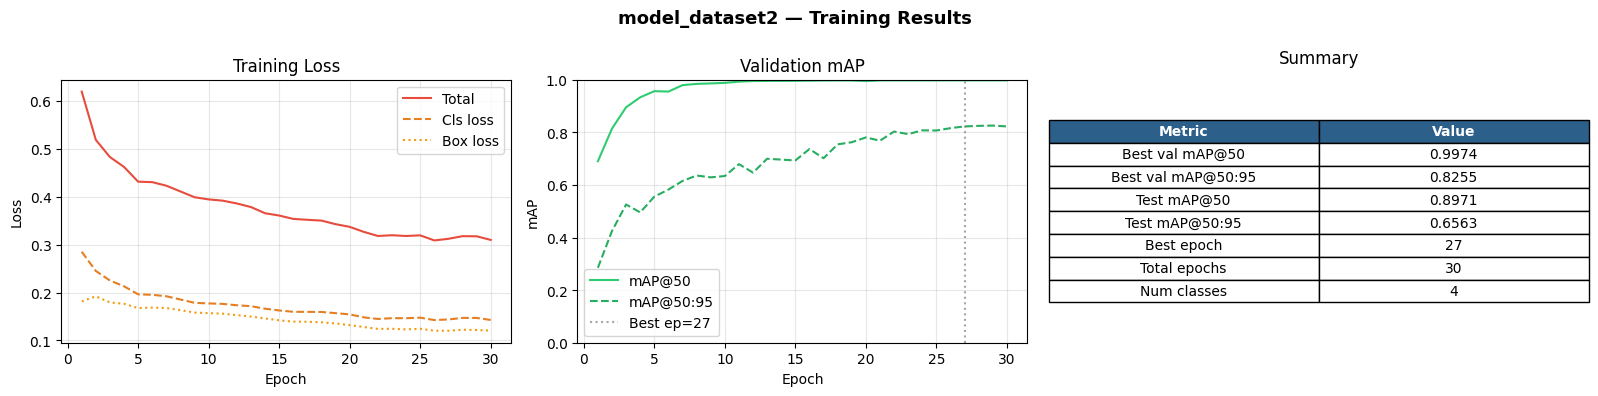

  📊 Training curve → /kaggle/working/ds2_outputs/model_dataset2/training_curve.png

  ✅ All results saved to: /kaggle/working/ds2_outputs/model_dataset2

📁 Results → /kaggle/working/ds2_outputs/model_dataset2/


In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 13: Train Dataset 2 model
# Results saved automatically to: output_dir/model_dataset2/
# ─────────────────────────────────────────────────────────────────────────────

NUM_CLASSES_DS2 = len(CFG['classes_ds2'])  # includes background

model2, history2, test_metrics2 = train_model(
    model_name    = 'model_dataset2',
    train_samples = ds2_train,
    val_samples   = ds2_val,
    test_samples  = ds2_test,
    num_classes   = NUM_CLASSES_DS2,
    cfg           = CFG,
    class_names   = CFG['classes_ds2']
)

print(f'\n📁 Results → {CFG["output_dir"]}/model_dataset2/')


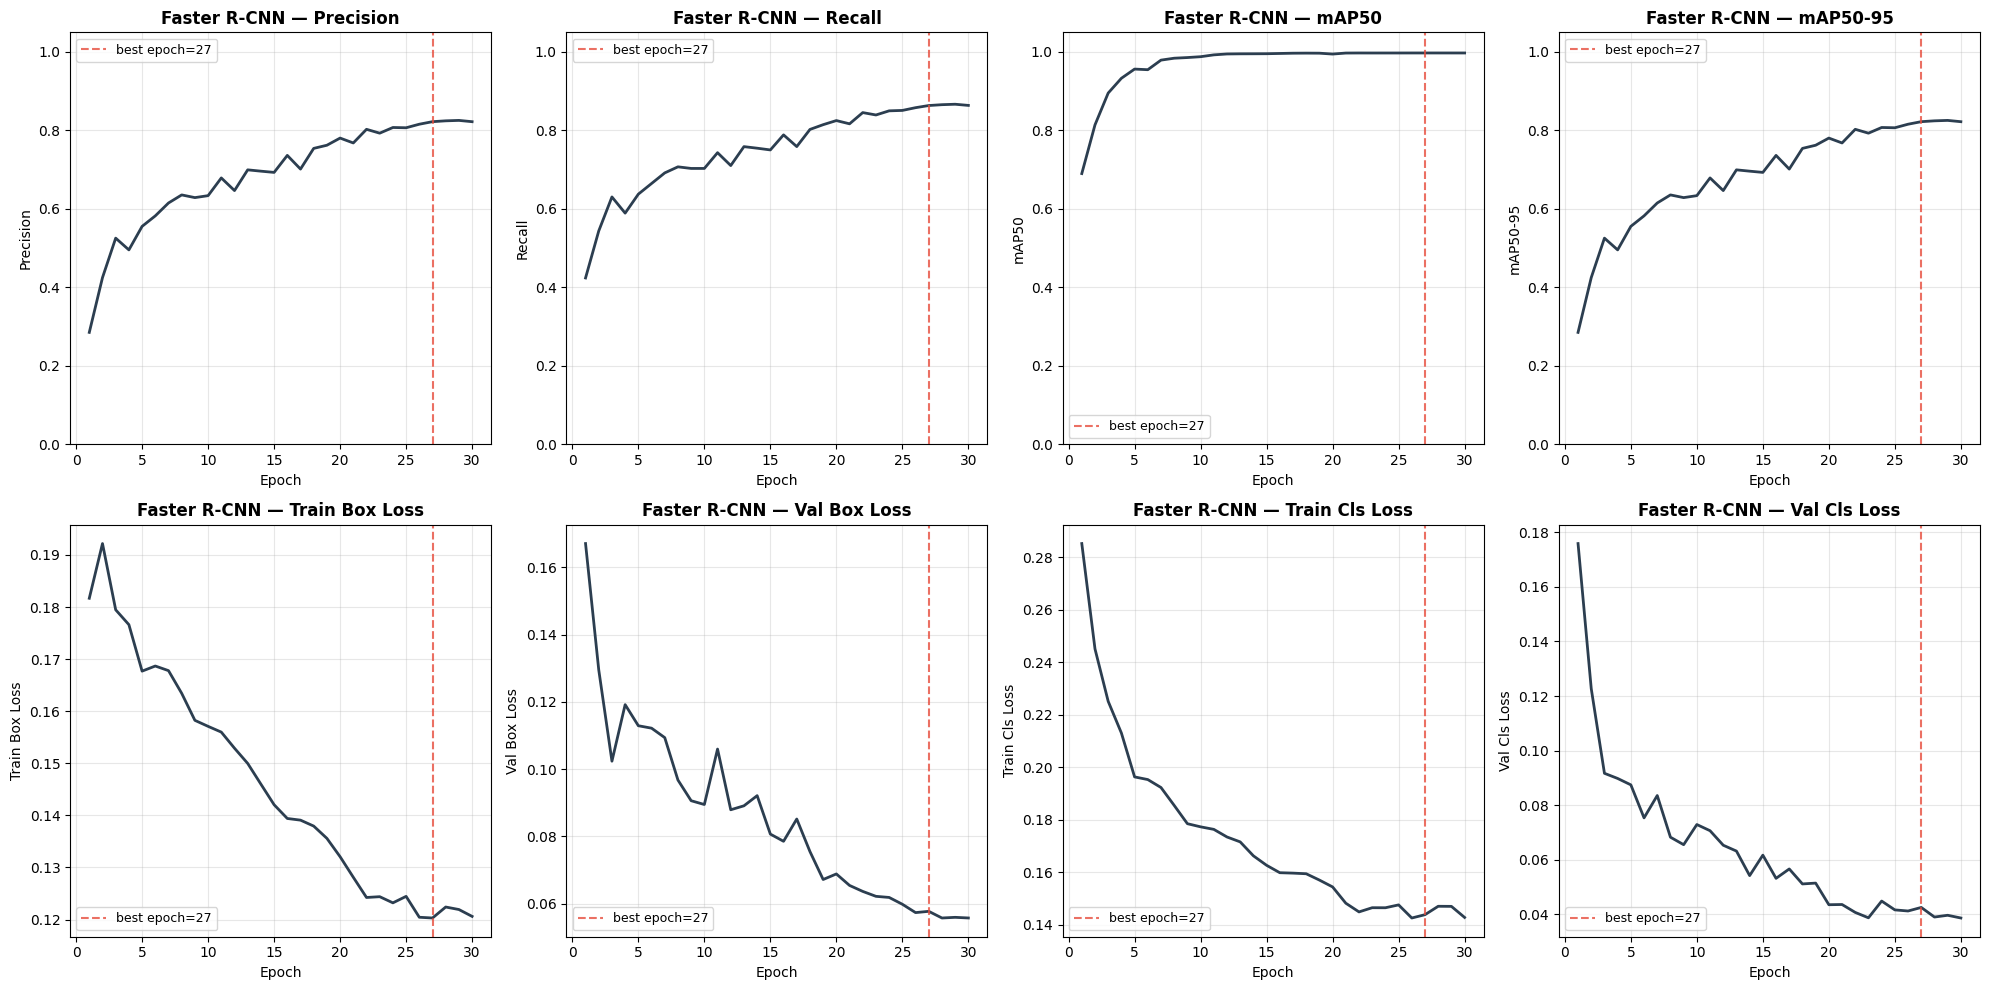

In [51]:
# ─── Cell 14a: Training Curves (YOLOv11 8-Panel Style) ────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_training_history_yolo_style(history, model_name, save_path=None):
    # The 8 metrics tracked in standard YOLO training
    plots = [
        ('precision', 'Precision'),
        ('recall', 'Recall'),
        ('val_map50', 'mAP50'),
        ('val_map595', 'mAP50-95'),
        ('train_loss_box', 'Train Box Loss'),
        ('val_loss_box', 'Val Box Loss'),
        ('train_loss_cls', 'Train Cls Loss'),
        ('val_loss_cls', 'Val Cls Loss')
    ]
    
    ep_range = range(1, len(history['val_map50']) + 1)
    best_ep = int(np.argmax(history['val_map50'])) + 1
    
    # Filter only metrics that actually exist in your history dictionary
    valid_plots = [(key, title) for key, title in plots if key in history and len(history[key]) > 0]
    
    n = len(valid_plots)
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
    axes_flat = axes.flatten() if n > 1 else [axes]
    
    for ax, (key, title) in zip(axes_flat, valid_plots):
        sns.lineplot(x=ep_range, y=history[key], ax=ax, linewidth=2, color='#2c3e50')
        ax.axvline(best_ep, ls='--', color='#e74c3c', alpha=0.8, label=f'best epoch={best_ep}')
        ax.set_title(f'Faster R-CNN — {title}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        
        # Standardize y-limits for accuracy metrics
        if key in ['precision', 'recall', 'val_map50', 'val_map595']:
            ax.set_ylim(0, 1.05)

    # Hide any empty subplots if metrics are missing
    for ax in axes_flat[n:]: 
        ax.set_visible(False)
        
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

# Run the plot
plot_training_history_yolo_style(
    history2, 
    'Dataset2 Model',
    save_path=f"{CFG['output_dir']}/plots/yolo_style_curves.png"
)

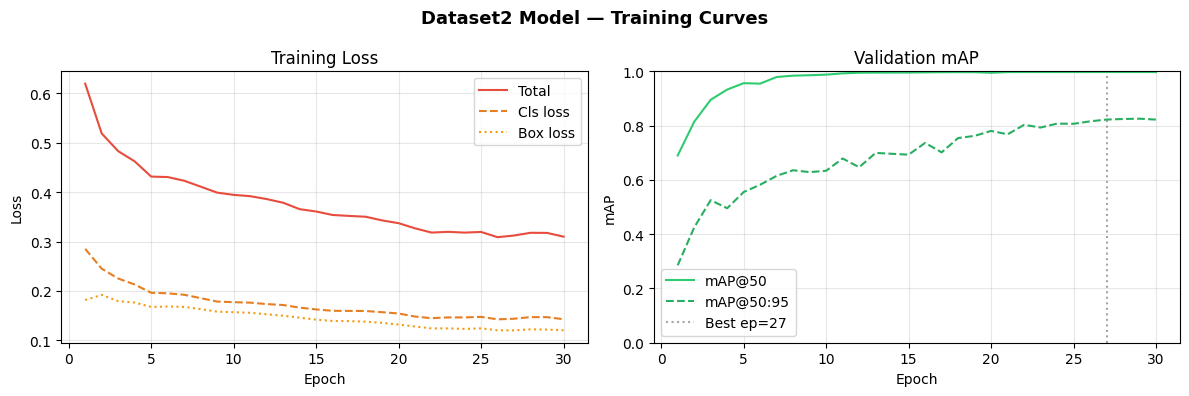

In [52]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 14b: Plot training curves
# ─────────────────────────────────────────────────────────────────────────────

def plot_training_history(history: dict, model_name: str, save_path: str = None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ep_range = list(range(1, len(history['train_loss']) + 1))

    axes[0].plot(ep_range, history['train_loss'],     label='Total',    color='#e74c3c')
    axes[0].plot(ep_range, history['train_loss_cls'], label='Cls loss', color='#e67e22', linestyle='--')
    axes[0].plot(ep_range, history['train_loss_box'], label='Box loss', color='#f39c12', linestyle=':')
    axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep_range, history['val_map50'],  label='mAP@50',    color='#2ecc71')
    axes[1].plot(ep_range, history['val_map595'], label='mAP@50:95', color='#27ae60', linestyle='--')
    best_ep = int(np.argmax(history['val_map50'])) + 1
    axes[1].axvline(best_ep, color='gray', linestyle=':', alpha=0.7, label=f'Best ep={best_ep}')
    axes[1].set_title('Validation mAP'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('mAP')
    axes[1].legend(); axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0, 1)

    plt.suptitle(f'{model_name} — Training Curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
    plt.show()


plot_training_history(
    history2, 'Dataset2 Model',
    save_path=f"{CFG['output_dir']}/plots/training_curves.png"
)


### 📈 Precision / Recall / mAP Combined Curves


💾 Saved → /kaggle/working/ds2_outputs/plots/precision_recall_map_combined.png


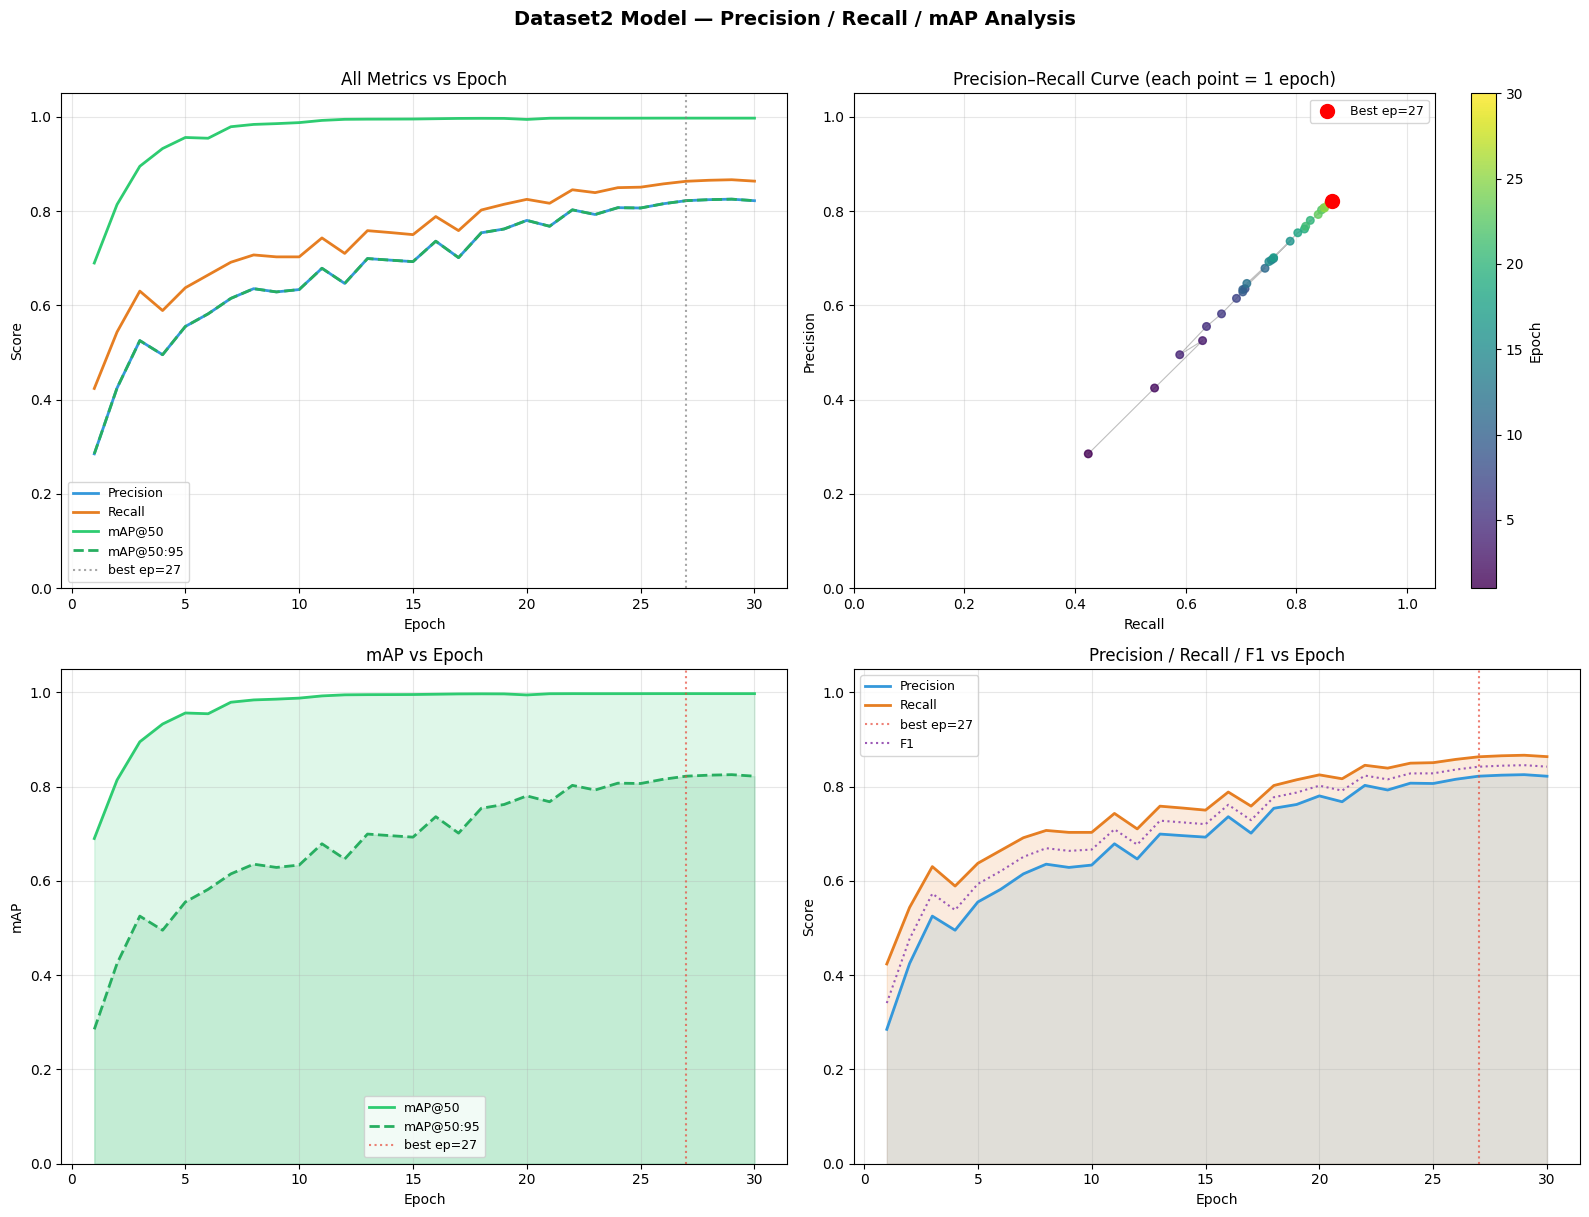

In [53]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 14c: 📈 Combined Precision / Recall / mAP curves (all in one figure)
# ─────────────────────────────────────────────────────────────────────────────

def plot_precision_recall_map_combined(history: dict, model_name: str, save_path: str = None):
    """
    One figure, four panels:
      1. Precision, Recall, mAP@50, mAP@50:95 — all on a single axis
      2. Precision vs Recall curve (parametric, epoch = parameter)
      3. mAP@50 and mAP@50:95 vs Epoch
      4. Precision and Recall vs Epoch
    """
    ep = list(range(1, len(history['val_map50']) + 1))
    best_ep = int(np.argmax(history['val_map50'])) + 1

    prec   = history.get('precision', [0]*len(ep))
    recall = history.get('recall',    [0]*len(ep))
    map50  = history['val_map50']
    map595 = history['val_map595']

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{model_name} — Precision / Recall / mAP Analysis',
                 fontsize=14, fontweight='bold', y=1.01)

    # ── 1. All metrics together ──────────────────────────────────────────────
    ax = axes[0, 0]
    ax.plot(ep, prec,   label='Precision',   color='#3498db', linewidth=2)
    ax.plot(ep, recall, label='Recall',      color='#e67e22', linewidth=2)
    ax.plot(ep, map50,  label='mAP@50',      color='#2ecc71', linewidth=2)
    ax.plot(ep, map595, label='mAP@50:95',   color='#27ae60', linewidth=2, linestyle='--')
    ax.axvline(best_ep, color='gray', linestyle=':', alpha=0.7, label=f'best ep={best_ep}')
    ax.set_title('All Metrics vs Epoch'); ax.set_xlabel('Epoch'); ax.set_ylabel('Score')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.05)

    # ── 2. P-R curve (parametric: each point = one epoch) ───────────────────
    ax2 = axes[0, 1]
    sc = ax2.scatter(recall, prec, c=ep, cmap='viridis', s=30, zorder=3, alpha=0.8)
    ax2.plot(recall, prec, color='gray', linewidth=0.8, alpha=0.5)
    # Mark best epoch
    if best_ep - 1 < len(recall):
        ax2.scatter([recall[best_ep-1]], [prec[best_ep-1]],
                    color='red', s=100, zorder=5, label=f'Best ep={best_ep}')
    plt.colorbar(sc, ax=ax2, label='Epoch')
    ax2.set_title('Precision–Recall Curve (each point = 1 epoch)')
    ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 1.05); ax2.set_ylim(0, 1.05)

    # ── 3. mAP@50 and mAP@50:95 vs Epoch ────────────────────────────────────
    ax3 = axes[1, 0]
    ax3.fill_between(ep, 0, map50,  alpha=0.15, color='#2ecc71')
    ax3.fill_between(ep, 0, map595, alpha=0.15, color='#27ae60')
    ax3.plot(ep, map50,  label='mAP@50',    color='#2ecc71', linewidth=2)
    ax3.plot(ep, map595, label='mAP@50:95', color='#27ae60', linewidth=2, linestyle='--')
    ax3.axvline(best_ep, color='#e74c3c', linestyle=':', alpha=0.7, label=f'best ep={best_ep}')
    ax3.set_title('mAP vs Epoch'); ax3.set_xlabel('Epoch'); ax3.set_ylabel('mAP')
    ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3); ax3.set_ylim(0, 1.05)

    # ── 4. Precision and Recall vs Epoch ─────────────────────────────────────
    ax4 = axes[1, 1]
    ax4.fill_between(ep, 0, prec,   alpha=0.15, color='#3498db')
    ax4.fill_between(ep, 0, recall, alpha=0.15, color='#e67e22')
    ax4.plot(ep, prec,   label='Precision', color='#3498db', linewidth=2)
    ax4.plot(ep, recall, label='Recall',    color='#e67e22', linewidth=2)
    ax4.axvline(best_ep, color='#e74c3c', linestyle=':', alpha=0.7, label=f'best ep={best_ep}')
    # F1 line
    f1 = [2*p*r/(p+r+1e-9) for p, r in zip(prec, recall)]
    ax4.plot(ep, f1, label='F1', color='#9b59b6', linewidth=1.5, linestyle=':')
    ax4.set_title('Precision / Recall / F1 vs Epoch'); ax4.set_xlabel('Epoch'); ax4.set_ylabel('Score')
    ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3); ax4.set_ylim(0, 1.05)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Saved → {save_path}')
    plt.show()


plot_precision_recall_map_combined(
    history2, 'Dataset2 Model',
    save_path=f"{CFG['output_dir']}/plots/precision_recall_map_combined.png"
)


### 📉 Loss Curves (All Components)


💾 Saved → /kaggle/working/ds2_outputs/plots/loss_curves.png


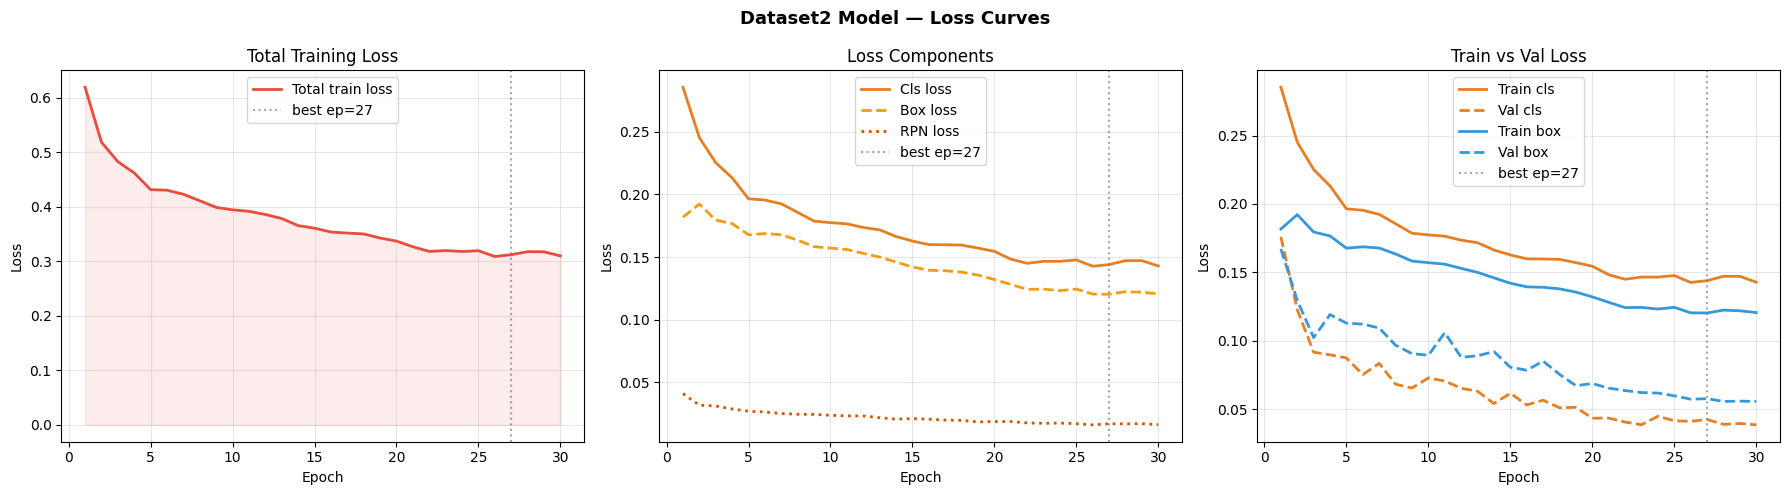

In [54]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 14d: 📉 Loss Curves (Train + Val, all components)
# ─────────────────────────────────────────────────────────────────────────────

def plot_loss_curves(history: dict, model_name: str, save_path: str = None):
    """
    Three-panel loss visualization:
      1. Total train loss vs epoch
      2. Train cls / box / rpn losses on same axis
      3. Train vs Val cls and box losses side by side
    """
    ep = list(range(1, len(history['train_loss']) + 1))
    best_ep = int(np.argmax(history['val_map50'])) + 1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{model_name} — Loss Curves', fontsize=13, fontweight='bold')

    # Panel 1: Total loss
    ax = axes[0]
    ax.plot(ep, history['train_loss'], color='#e74c3c', linewidth=2, label='Total train loss')
    ax.fill_between(ep, 0, history['train_loss'], alpha=0.1, color='#e74c3c')
    ax.axvline(best_ep, color='gray', linestyle=':', alpha=0.7, label=f'best ep={best_ep}')
    ax.set_title('Total Training Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Panel 2: Loss components
    ax2 = axes[1]
    ax2.plot(ep, history['train_loss_cls'], color='#e67e22', linewidth=2, label='Cls loss')
    ax2.plot(ep, history['train_loss_box'], color='#f39c12', linewidth=2, label='Box loss', linestyle='--')
    if history.get('train_loss_rpn'):
        ax2.plot(ep, history['train_loss_rpn'], color='#d35400', linewidth=2, label='RPN loss', linestyle=':')
    ax2.axvline(best_ep, color='gray', linestyle=':', alpha=0.7, label=f'best ep={best_ep}')
    ax2.set_title('Loss Components'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    # Panel 3: Train vs Val
    ax3 = axes[2]
    if history.get('val_loss_cls') and any(v > 0 for v in history['val_loss_cls']):
        ax3.plot(ep, history['train_loss_cls'], color='#e67e22', linewidth=2, label='Train cls')
        ax3.plot(ep, history['val_loss_cls'],   color='#e67e22', linewidth=2, linestyle='--', label='Val cls')
    if history.get('val_loss_box') and any(v > 0 for v in history['val_loss_box']):
        ax3.plot(ep, history['train_loss_box'], color='#3498db', linewidth=2, label='Train box')
        ax3.plot(ep, history['val_loss_box'],   color='#3498db', linewidth=2, linestyle='--', label='Val box')
    ax3.axvline(best_ep, color='gray', linestyle=':', alpha=0.7, label=f'best ep={best_ep}')
    ax3.set_title('Train vs Val Loss'); ax3.set_xlabel('Epoch'); ax3.set_ylabel('Loss')
    ax3.legend(); ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Saved → {save_path}')
    plt.show()


plot_loss_curves(
    history2, 'Dataset2 Model',
    save_path=f"{CFG['output_dir']}/plots/loss_curves.png"
)


### 📊 F1–Confidence Visualization


  Computing P/R/F1 at each confidence threshold (this takes a moment)...


💾 Saved → /kaggle/working/ds2_outputs/plots/f1_confidence.png


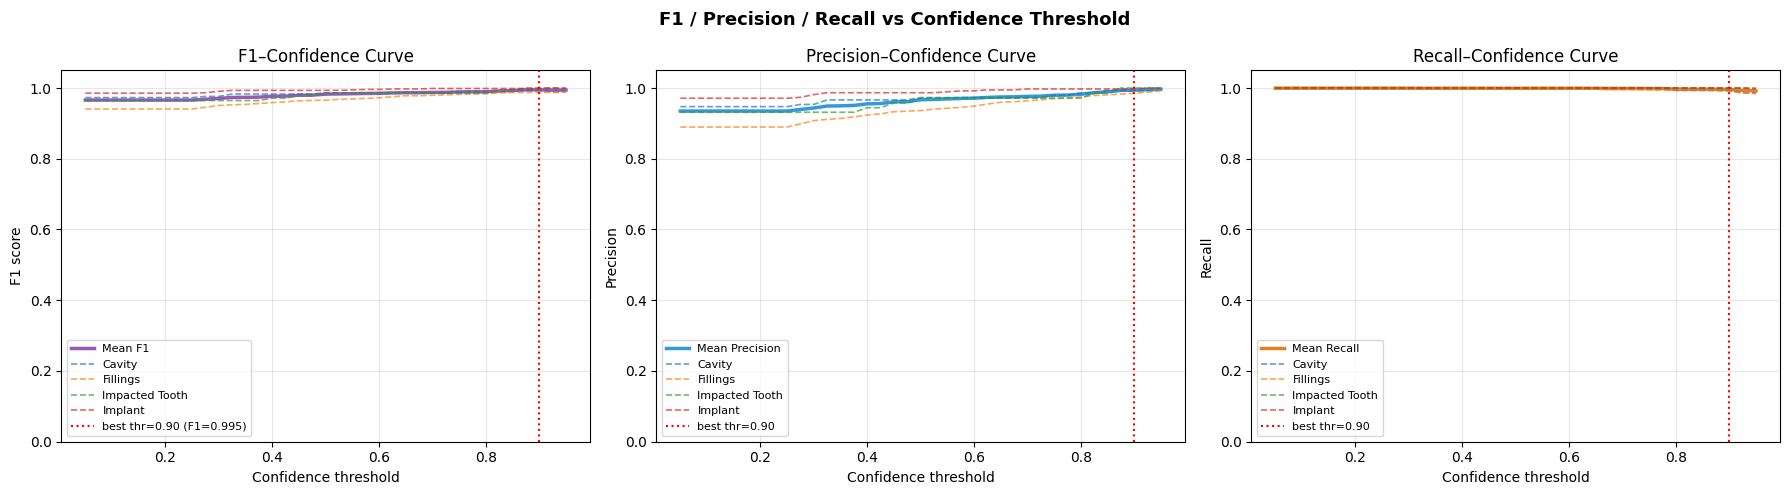


  Best confidence threshold: 0.90  →  Mean F1 = 0.9949
  (Use CFG["min_score"] = 0.90 for inference)


In [55]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 14e: 📊 F1–Confidence Curve
# Sweeps confidence thresholds [0.05..0.95], computes P/R/F1 at each threshold
# on the validation set, and plots the classic F1-confidence curve.
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def compute_pr_at_thresholds(model, loader, num_classes, device,
                              thresholds=None, iou_thr=0.5):
    """
    For each confidence threshold compute per-class and mean precision, recall, F1.
    Returns dict: threshold -> {precision, recall, f1, per_class: {cls: {p,r,f1}}}
    """
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 37).tolist()

    model.eval()
    # ── Collect all predictions with score > 0.01 (low bar to get all data) ──
    all_preds, all_targets = [], []
    for images, targets in tqdm(loader, desc='  collecting predictions', leave=False):
        images = [img.to(device) for img in images]
        with torch.cuda.amp.autocast(enabled=device.type == 'cuda'):
            outputs = model(images)
        for out, tgt in zip(outputs, targets):
            mask = out['scores'] >= 0.01
            all_preds.append({
                'boxes':  out['boxes'][mask].cpu(),
                'scores': out['scores'][mask].cpu(),
                'labels': out['labels'][mask].cpu(),
            })
            all_targets.append({
                'boxes':  tgt['boxes'].cpu(),
                'labels': tgt['labels'].cpu(),
            })

    results = {}
    for thr in thresholds:
        cls_tp = defaultdict(int); cls_fp = defaultdict(int); cls_fn = defaultdict(int)
        for pred, tgt in zip(all_preds, all_targets):
            mask = pred['scores'] >= thr
            p_boxes  = pred['boxes'][mask]
            p_labels = pred['labels'][mask]
            gt_boxes  = tgt['boxes']
            gt_labels = tgt['labels']

            for cls in range(1, num_classes):
                pm = p_labels == cls
                gm = gt_labels == cls
                pb = p_boxes[pm]; gb = gt_boxes[gm]
                ngt = len(gb); npred = len(pb)

                if ngt == 0 and npred == 0:
                    continue
                if npred == 0:
                    cls_fn[cls] += ngt; continue
                if ngt == 0:
                    cls_fp[cls] += npred; continue

                from torchvision.ops import box_iou as tv_box_iou
                iou_mat = tv_box_iou(pb, gb)
                matched_gt = set()
                for pi in range(len(pb)):
                    best_iou, best_gt = iou_mat[pi].max(0)
                    if best_iou >= iou_thr and best_gt.item() not in matched_gt:
                        cls_tp[cls] += 1
                        matched_gt.add(best_gt.item())
                    else:
                        cls_fp[cls] += 1
                cls_fn[cls] += ngt - len(matched_gt)

        pc = {}
        for cls in range(1, num_classes):
            tp = cls_tp[cls]; fp = cls_fp[cls]; fn = cls_fn[cls]
            p  = tp / (tp + fp + 1e-9)
            r  = tp / (tp + fn + 1e-9)
            f1 = 2 * p * r / (p + r + 1e-9)
            pc[cls] = {'p': p, 'r': r, 'f1': f1}

        all_p  = np.mean([v['p']  for v in pc.values()]) if pc else 0
        all_r  = np.mean([v['r']  for v in pc.values()]) if pc else 0
        all_f1 = np.mean([v['f1'] for v in pc.values()]) if pc else 0
        results[round(thr, 3)] = {'precision': all_p, 'recall': all_r, 'f1': all_f1, 'per_class': pc}

    return results


def plot_f1_confidence(model, val_samples, num_classes, class_names, cfg,
                       save_path=None):
    """
    Computes and plots:
      - F1-Confidence curve (mean + per class)
      - Precision-Confidence curve
      - Recall-Confidence curve
    """
    val_ds     = DentalDataset(val_samples, VAL_TRANSFORM, cfg['image_size'], balance_to=0)
    val_loader = DataLoader(val_ds, batch_size=2, shuffle=False,
                            collate_fn=collate_fn, num_workers=2)

    print('  Computing P/R/F1 at each confidence threshold (this takes a moment)...')
    thresholds = np.linspace(0.05, 0.95, 37).tolist()
    pr_data    = compute_pr_at_thresholds(model, val_loader, num_classes, DEVICE, thresholds)

    thrs  = sorted(pr_data.keys())
    mean_f1   = [pr_data[t]['f1']        for t in thrs]
    mean_prec = [pr_data[t]['precision'] for t in thrs]
    mean_rec  = [pr_data[t]['recall']    for t in thrs]

    best_thr_idx = int(np.argmax(mean_f1))
    best_thr     = thrs[best_thr_idx]
    best_f1      = mean_f1[best_thr_idx]

    COLORS = plt.colormaps['tab10'].colors
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('F1 / Precision / Recall vs Confidence Threshold',
                 fontsize=13, fontweight='bold')

    # F1 – confidence
    ax = axes[0]
    ax.plot(thrs, mean_f1, color='#9b59b6', linewidth=2.5, label=f'Mean F1')
    for i, cls in enumerate(range(1, num_classes)):
        cls_f1 = [pr_data[t]['per_class'].get(cls, {}).get('f1', 0) for t in thrs]
        nm = class_names[cls] if cls < len(class_names) else f'cls{cls}'
        ax.plot(thrs, cls_f1, linewidth=1.2, alpha=0.7,
                color=COLORS[i % len(COLORS)], linestyle='--', label=nm)
    ax.axvline(best_thr, color='red', linestyle=':', linewidth=1.5,
               label=f'best thr={best_thr:.2f} (F1={best_f1:.3f})')
    ax.set_title('F1–Confidence Curve'); ax.set_xlabel('Confidence threshold')
    ax.set_ylabel('F1 score'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

    # Precision – confidence
    ax2 = axes[1]
    ax2.plot(thrs, mean_prec, color='#3498db', linewidth=2.5, label='Mean Precision')
    for i, cls in enumerate(range(1, num_classes)):
        cls_p = [pr_data[t]['per_class'].get(cls, {}).get('p', 0) for t in thrs]
        nm = class_names[cls] if cls < len(class_names) else f'cls{cls}'
        ax2.plot(thrs, cls_p, linewidth=1.2, alpha=0.7,
                 color=COLORS[i % len(COLORS)], linestyle='--', label=nm)
    ax2.axvline(best_thr, color='red', linestyle=':', linewidth=1.5, label=f'best thr={best_thr:.2f}')
    ax2.set_title('Precision–Confidence Curve'); ax2.set_xlabel('Confidence threshold')
    ax2.set_ylabel('Precision'); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1.05)

    # Recall – confidence
    ax3 = axes[2]
    ax3.plot(thrs, mean_rec, color='#e67e22', linewidth=2.5, label='Mean Recall')
    for i, cls in enumerate(range(1, num_classes)):
        cls_r = [pr_data[t]['per_class'].get(cls, {}).get('r', 0) for t in thrs]
        nm = class_names[cls] if cls < len(class_names) else f'cls{cls}'
        ax3.plot(thrs, cls_r, linewidth=1.2, alpha=0.7,
                 color=COLORS[i % len(COLORS)], linestyle='--', label=nm)
    ax3.axvline(best_thr, color='red', linestyle=':', linewidth=1.5, label=f'best thr={best_thr:.2f}')
    ax3.set_title('Recall–Confidence Curve'); ax3.set_xlabel('Confidence threshold')
    ax3.set_ylabel('Recall'); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)
    ax3.set_ylim(0, 1.05)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Saved → {save_path}')
    plt.show()
    print(f'\n  Best confidence threshold: {best_thr:.2f}  →  Mean F1 = {best_f1:.4f}')
    print(f'  (Use CFG["min_score"] = {best_thr:.2f} for inference)')
    return best_thr


best_conf_thr = plot_f1_confidence(
    model2, ds2_val, NUM_CLASSES_DS2, CFG['classes_ds2'], CFG,
    save_path=f"{CFG['output_dir']}/plots/f1_confidence.png"
)


### 🔲 Confusion Matrix


💾 Saved → /kaggle/working/ds2_outputs/plots/confusion_matrix.png


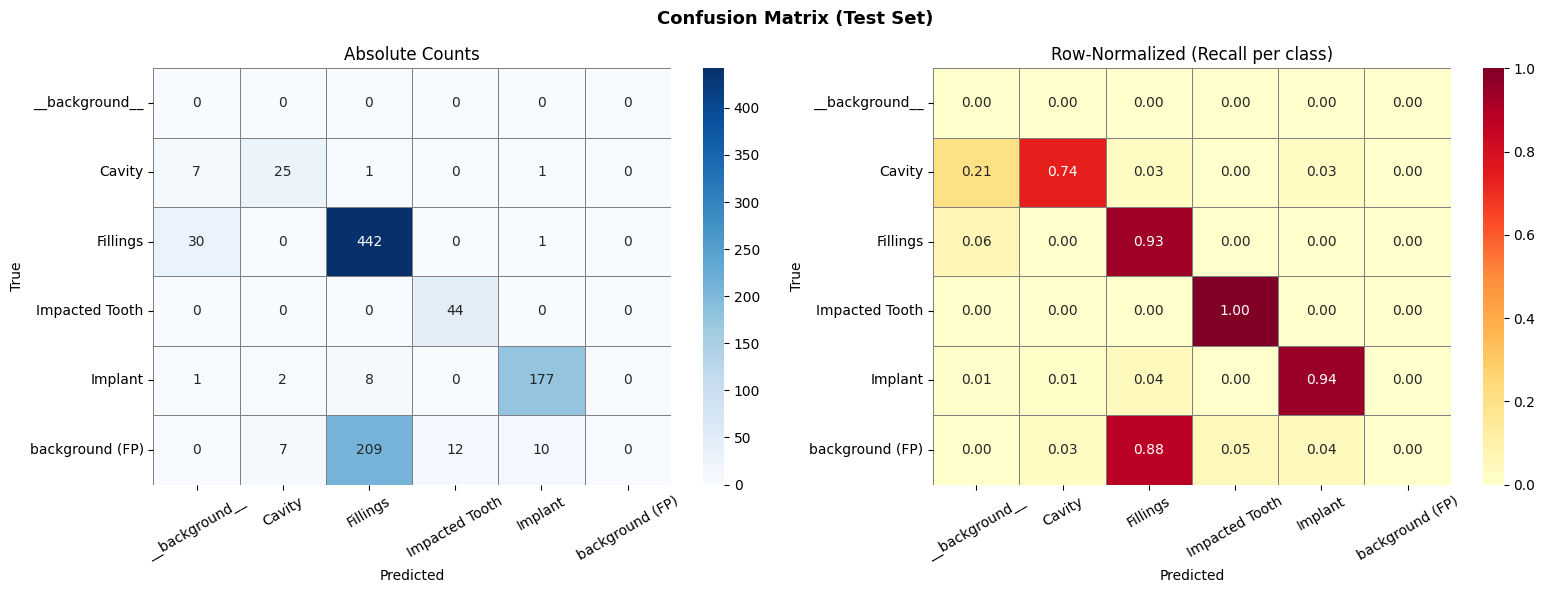


Per-class stats from confusion matrix:
  Class                    TP     FP     FN     Prec      Rec
  ──────────────────────────────────────────────────────────
  __background__            0      0      0    0.000    0.000
  Cavity                   25      7      7    0.781    0.781
  Fillings                442    209     30    0.679    0.936
  Impacted Tooth           44     12      0    0.786    1.000
  Implant                 177     10      1    0.947    0.994


In [56]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 14f: 🔲 Confusion Matrix (on test set)
# Rows = true class, Cols = predicted class.
# Background (FP with no matching GT) shown as "background" class.
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def compute_confusion_matrix(model, test_samples, num_classes, class_names,
                              cfg, iou_thr=0.5, save_path=None):
    """
    Build a (num_classes+1) × (num_classes+1) confusion matrix.
      Rows = ground-truth class (+ 'background' for FP)
      Cols = predicted class   (+ 'background' for FN/missed)
    """
    from torchvision.ops import box_iou as tv_box_iou

    n = num_classes + 1       # +1 for explicit 'background' column
    cm = np.zeros((n, n), dtype=np.int32)

    test_ds     = DentalDataset(test_samples, VAL_TRANSFORM, cfg['image_size'], balance_to=0)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                             collate_fn=collate_fn, num_workers=0)
    model.eval()

    for images, targets in tqdm(test_loader, desc='  confusion matrix', leave=False):
        images = [img.to(DEVICE) for img in images]
        with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):
            outputs = model(images)

        for out, tgt in zip(outputs, targets):
            score_mask = out['scores'] >= cfg['min_score']
            pred_boxes  = out['boxes'][score_mask].cpu()
            pred_labels = out['labels'][score_mask].cpu()
            gt_boxes    = tgt['boxes'].cpu()
            gt_labels   = tgt['labels'].cpu()

            if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                continue

            # ── Match predictions to GT ──────────────────────────────────
            gt_matched   = [False] * len(gt_boxes)
            pred_matched = [False] * len(pred_boxes)

            if len(gt_boxes) > 0 and len(pred_boxes) > 0:
                iou_mat = tv_box_iou(pred_boxes, gt_boxes)  # (P, G)
                # Greedy matching (highest IoU first)
                ious_flat = iou_mat.reshape(-1)
                order = ious_flat.argsort(descending=True)
                for idx in order:
                    pi, gi = divmod(idx.item(), len(gt_boxes))
                    if iou_mat[pi, gi] < iou_thr:
                        break
                    if pred_matched[pi] or gt_matched[gi]:
                        continue
                    pred_matched[pi] = True
                    gt_matched[gi]   = True
                    # True class (row) → predicted class (col)
                    true_cls = gt_labels[gi].item()
                    pred_cls = pred_labels[pi].item()
                    cm[true_cls, pred_cls] += 1

            # ── FN: unmatched GT → predicted as background (col=0) ────────
            for gi, (matched, gt_cls) in enumerate(zip(gt_matched, gt_labels)):
                if not matched:
                    cm[gt_cls.item(), 0] += 1

            # ── FP: unmatched preds → 'background' GT (row=n-1 = BG row) ──
            for pi, (matched, pred_cls) in enumerate(zip(pred_matched, pred_labels)):
                if not matched:
                    cm[num_classes, pred_cls.item()] += 1

    # ── Plot ──────────────────────────────────────────────────────────────────
    labels = list(class_names) + ['background (FP)']
    # Use only rows/cols that have any data
    active = [i for i in range(n) if cm[i].sum() > 0 or cm[:, i].sum() > 0]
    cm_plot = cm[np.ix_(active, active)]
    labels_plot = [labels[i] if i < len(labels) else f'cls{i}' for i in active]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')

    # Absolute counts
    ax = axes[0]
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_plot, yticklabels=labels_plot, ax=ax,
                linewidths=0.5, linecolor='gray')
    ax.set_title('Absolute Counts')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)

    # Normalized (per-row)
    row_sums = cm_plot.sum(axis=1, keepdims=True).clip(min=1)
    cm_norm  = cm_plot / row_sums
    ax2 = axes[1]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=labels_plot, yticklabels=labels_plot, ax=ax2,
                linewidths=0.5, linecolor='gray', vmin=0, vmax=1)
    ax2.set_title('Row-Normalized (Recall per class)')
    ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')
    ax2.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Saved → {save_path}')
    plt.show()

    # Print class-level accuracy
    print('\nPer-class stats from confusion matrix:')
    print(f'  {"Class":<20} {"TP":>6} {"FP":>6} {"FN":>6} {"Prec":>8} {"Rec":>8}')
    print('  ' + '─' * 58)
    for ai, cls_idx in enumerate(active):
        if cls_idx >= num_classes:
            continue
        nm  = labels[cls_idx] if cls_idx < len(labels) else f'cls{cls_idx}'
        tp  = cm_plot[ai, ai]
        fp  = cm_plot[num_classes, ai] if num_classes in active else cm[num_classes, cls_idx]
        fn  = cm_plot[ai, active.index(0)] if 0 in active else cm[cls_idx, 0]
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        print(f'  {nm:<20} {tp:>6} {fp:>6} {fn:>6} {prec:>8.3f} {rec:>8.3f}')

    return cm


confusion_mat = compute_confusion_matrix(
    model2, ds2_test, NUM_CLASSES_DS2, CFG['classes_ds2'], CFG,
    save_path=f"{CFG['output_dir']}/plots/confusion_matrix.png"
)


## 9. Evaluation


In [57]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 20: Collect test results
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd

print('\n── Model test results ─────────────────────────────────────────────')
print(f'  model_dataset2   mAP@50={test_metrics2["mAP@50"]:.4f}  '
      f'mAP@50:95={test_metrics2["mAP@50:95"]:.4f}')

df_results = pd.DataFrame([{
    'model': 'model_dataset2',
    'mAP@50': test_metrics2['mAP@50'],
    'mAP@50:95': test_metrics2['mAP@50:95'],
}])
df_results.to_csv(f"{CFG['output_dir']}/test_metrics.csv", index=False)
print(f"\n💾 Metrics saved → {CFG['output_dir']}/test_metrics.csv")



── Model test results ─────────────────────────────────────────────
  model_dataset2   mAP@50=0.8971  mAP@50:95=0.6563

💾 Metrics saved → /kaggle/working/ds2_outputs/test_metrics.csv


In [58]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 21: Per-class AP bar chart
# ─────────────────────────────────────────────────────────────────────────────

pc = test_metrics2.get('per_class_AP@50', {})
cls_names = CFG['classes_ds2']
if pc:
    ids   = sorted(pc.keys())
    vals  = [pc[k] for k in ids]
    names = [cls_names[int(k)] if int(k) < len(cls_names) else f'cls{k}' for k in ids]
    colors = ['#2ecc71' if v >= 0.5 else '#e67e22' if v >= 0.3 else '#e74c3c' for v in vals]

    fig, ax = plt.subplots(figsize=(8, max(3, len(names) * 0.6 + 1)))
    bars = ax.barh(names, vals, color=colors)
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
    ax.set_xlim(0, 1.1); ax.set_xlabel('AP@50')
    ax.set_title('Dataset 2 Model — Per-Class AP@50', fontweight='bold')
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 threshold')
    ax.legend(); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/plots/per_class_ap.png", dpi=120)
    plt.show()
    print(f'✅ Per-class AP chart saved.')


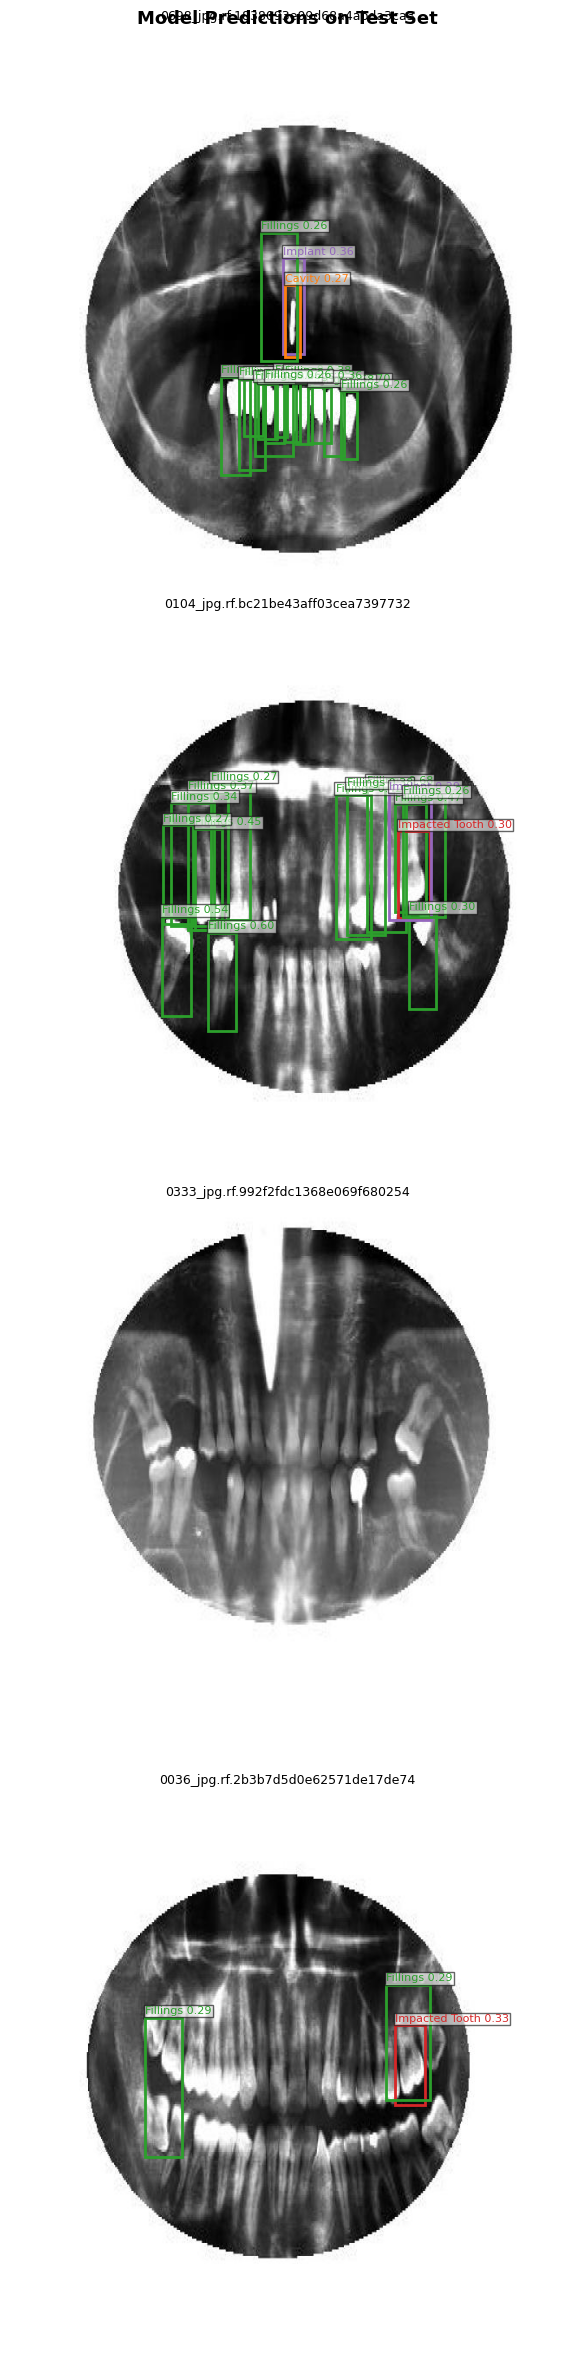

In [61]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 22: Visualize model predictions
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def visualize_single_model_predictions(
    model,
    samples,
    class_names,
    n=4,
    save_path=None,
):
    """
    Show n test images with predicted bounding boxes.
    - Loads and displays the ORIGINAL image (no normalization, no black padding).
    - Boxes are rescaled from the padded model-input space back to display space.
    """
    COLORS = plt.colormaps['tab10'].colors
    chosen = random.sample(samples, min(n, len(samples)))

    # Build inference dataset (normalized + padded — fed to model only)
    inf_ds = DentalDataset(chosen, VAL_TRANSFORM, CFG['image_size'], legacy_normalization=True)

    # Scale factor: model runs on CFG['image_size'] square; display on native size
    TARGET = CFG['image_size']

    ffig, axes = plt.subplots(len(chosen), 1, figsize=(20, 6 * len(chosen)))
    if len(chosen) == 1:
        axes = [axes]

    model.eval()
    for i, (ax, sample) in enumerate(zip(axes, chosen)):
        img_path = sample['image_path']

        # ── 1. Load original image for display ──────────────────────────────
        orig = cv2.imread(str(img_path))
        if orig is None:
            ax.set_facecolor('white')
            ax.text(0.5, 0.5, f'Could not load:\n{img_path.name}',
                    ha='center', va='center', transform=ax.transAxes, color='red')
            ax.axis('off')
            continue
        orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
        h, w = orig_rgb.shape[:2]

        # ── 2. Run inference on the padded/normalised tensor ─────────────────
        img_tensor, _ = inf_ds[i]
        with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):
            out = model([img_tensor.to(DEVICE)])[0]

        mask   = out['scores'] >= CFG['min_score']
        boxes  = out['boxes'][mask].cpu().numpy()   # in padded TARGET×TARGET space
        scores = out['scores'][mask].cpu().numpy()
        labels = out['labels'][mask].cpu().numpy()

        # ── 3. Rescale boxes from padded space → original image space ────────
        # LongestMaxSize scales so the longest side = TARGET
        scale  = TARGET / max(h, w)
        # PadIfNeeded centres the image; compute offsets
        new_h, new_w = int(h * scale), int(w * scale)
        pad_top  = (TARGET - new_h) // 2
        pad_left = (TARGET - new_w) // 2

        rescaled_boxes = []
        for box in boxes:
            x1, y1, x2, y2 = box
            # Remove padding offset, then undo scale
            x1 = (x1 - pad_left) / scale
            y1 = (y1 - pad_top)  / scale
            x2 = (x2 - pad_left) / scale
            y2 = (y2 - pad_top)  / scale
            # Clip to original image bounds
            x1, x2 = max(0, x1), min(w, x2)
            y1, y2 = max(0, y1), min(h, y2)
            rescaled_boxes.append((x1, y1, x2, y2))

        # ── 4. Display ───────────────────────────────────────────────────────
        ax.imshow(orig_rgb)
        for (x1, y1, x2, y2), score, cls_id in zip(rescaled_boxes, scores, labels):
            if x2 <= x1 or y2 <= y1:
                continue
            color = COLORS[int(cls_id) % len(COLORS)]
            rect  = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            lbl = class_names[int(cls_id)] if int(cls_id) < len(class_names) else str(int(cls_id))
            ax.text(x1, max(y1 - 4, 0), f'{lbl} {score:.2f}',
                    fontsize=8, color=color,
                    bbox=dict(facecolor='white', alpha=0.6, pad=1))

        ax.set_title(img_path.name[:35], fontsize=9)
        ax.axis('off')

    plt.suptitle('Model Predictions on Test Set', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()


if ds2_test:
    visualize_single_model_predictions(
        model2, ds2_test, CFG['classes_ds2'], n=4,
        save_path=f"{CFG['output_dir']}/plots/predictions.png"
    )


### 🖼️ Enhanced Predictions: GT vs Predictions Side-by-Side


💾 Saved → /kaggle/working/ds2_outputs/plots/predictions_gt_vs_pred.png


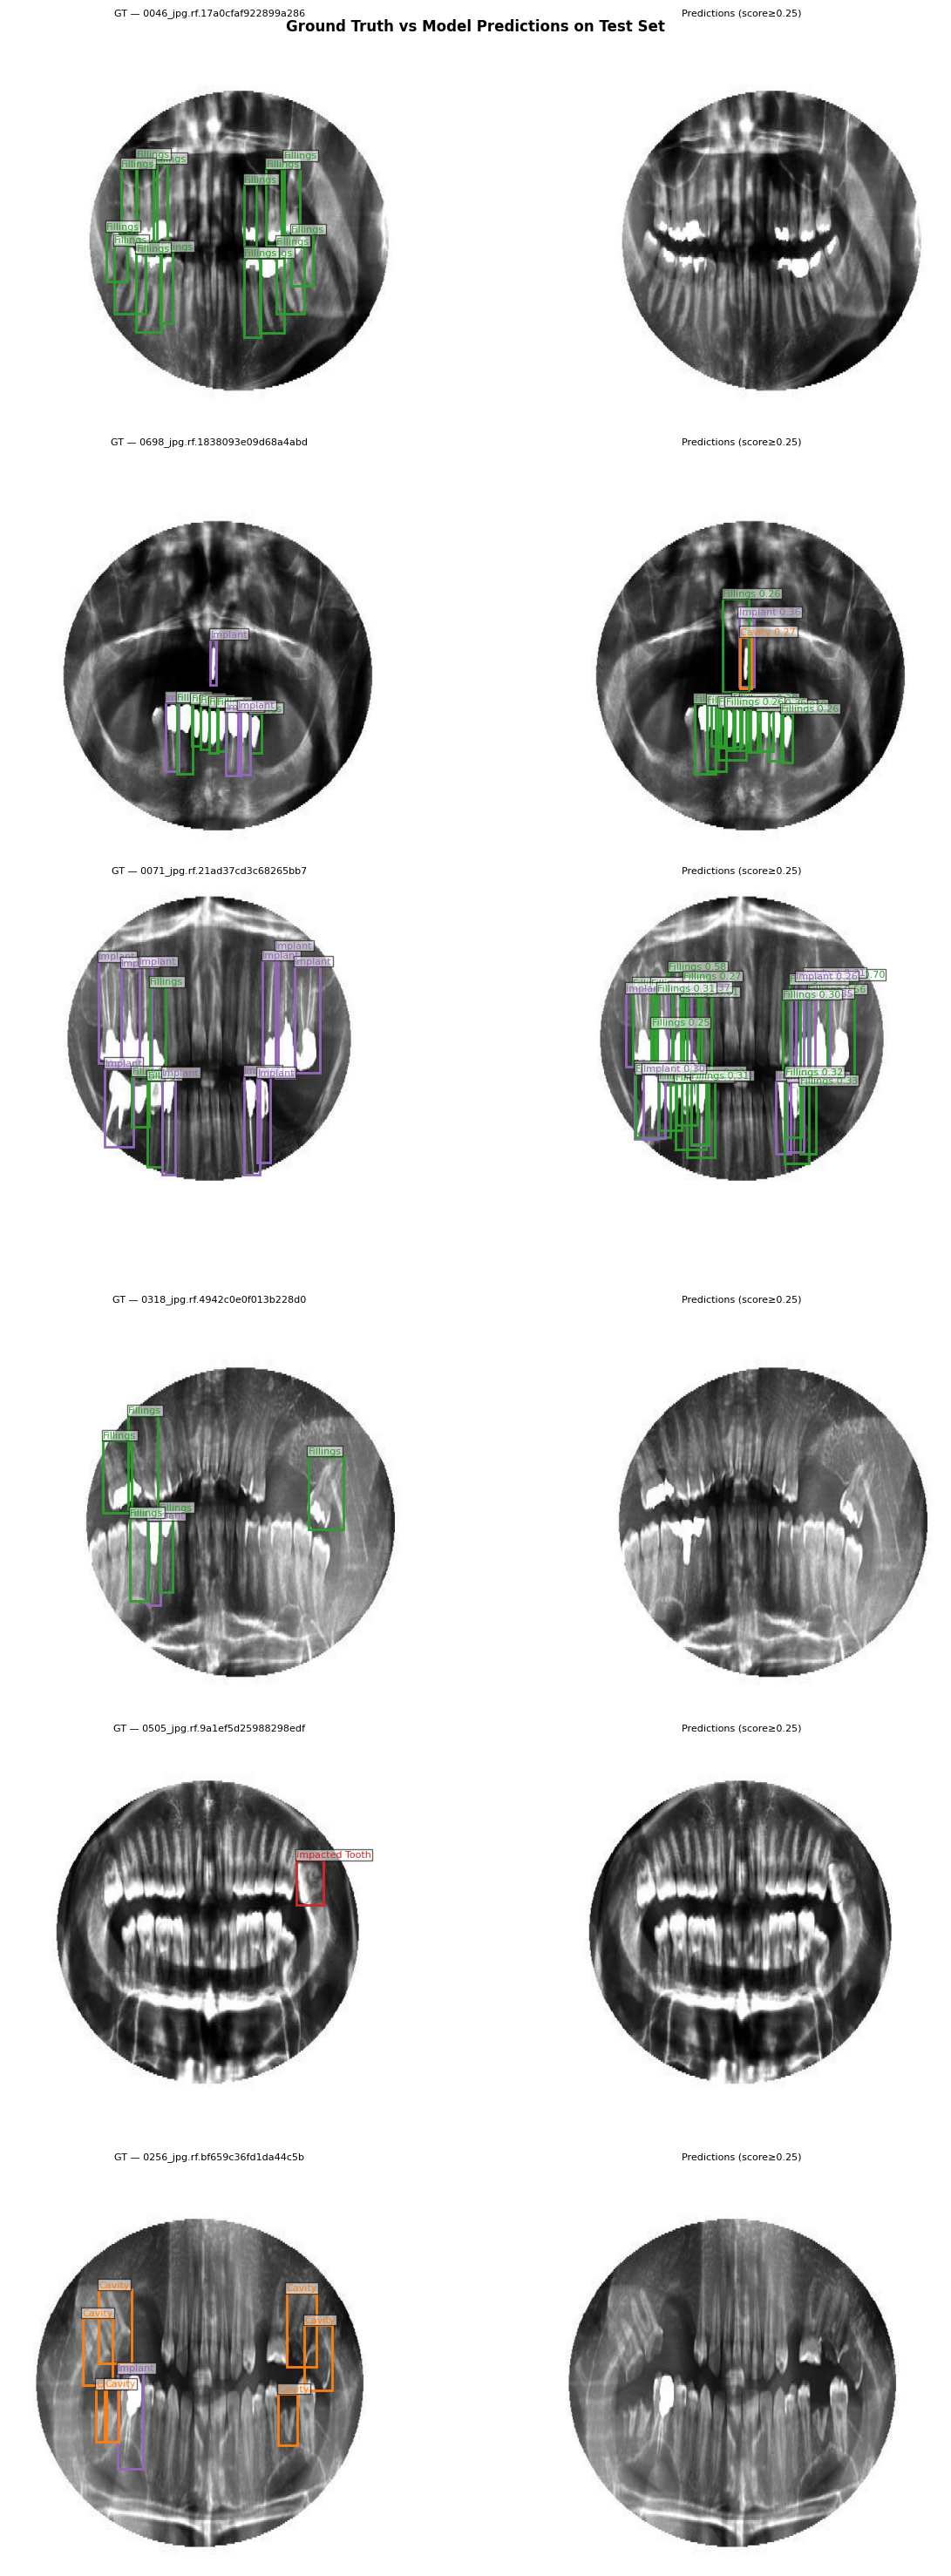

In [62]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 22b: 🖼️ Enhanced Sample Predictions (ground truth + predictions side-by-side)
# Shows 6 test images; each row = (GT view | Prediction view)
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def visualize_predictions_with_gt(model, samples, class_names, n=6, cfg=None,
                                   save_path=None):
    """
    For each selected image shows two panels side by side:
      Left  — Ground truth boxes (green)
      Right — Model predictions  (coloured by class)
    """
    if cfg is None:
        cfg = CFG
    COLORS = plt.colormaps['tab10'].colors
    TARGET = cfg['image_size']

    chosen  = random.sample(samples, min(n, len(samples)))
    inf_ds  = DentalDataset(chosen, VAL_TRANSFORM, TARGET, balance_to=0,
                            legacy_normalization=True)

    ncols = 2
    fig, axes = plt.subplots(len(chosen), ncols,
                             figsize=(14, 5 * len(chosen)))
    if len(chosen) == 1:
        axes = [axes]

    model.eval()
    for i, (row_axes, sample) in enumerate(zip(axes, chosen)):
        img_path = sample['image_path']
        # ── Load original image ──────────────────────────────────────────────
        orig = cv2.imread(str(img_path))
        if orig is None:
            for ax in row_axes:
                ax.text(0.5, 0.5, 'Could not load', ha='center', va='center',
                        transform=ax.transAxes); ax.axis('off')
            continue
        orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
        h, w = orig_rgb.shape[:2]

        # ── Run inference ────────────────────────────────────────────────────
        img_tensor, tgt = inf_ds[i]
        with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):
            out = model([img_tensor.to(DEVICE)])[0]

        mask   = out['scores'] >= cfg['min_score']
        pred_boxes  = out['boxes'][mask].cpu().numpy()
        pred_scores = out['scores'][mask].cpu().numpy()
        pred_labels = out['labels'][mask].cpu().numpy()

        # ── Rescale boxes ────────────────────────────────────────────────────
        scale  = TARGET / max(h, w)
        new_h  = int(h * scale); new_w = int(w * scale)
        pad_top  = (TARGET - new_h) // 2
        pad_left = (TARGET - new_w) // 2

        def rescale(boxes):
            out_boxes = []
            for b in boxes:
                x1,y1,x2,y2 = b
                x1=(x1-pad_left)/scale; y1=(y1-pad_top)/scale
                x2=(x2-pad_left)/scale; y2=(y2-pad_top)/scale
                out_boxes.append((max(0,x1),max(0,y1),min(w,x2),min(h,y2)))
            return out_boxes

        rescaled_pred = rescale(pred_boxes)

        # ── GT boxes ─────────────────────────────────────────────────────────
        gt_boxes_raw = sample['boxes']
        gt_labels = sample['labels']

        # ── Left: GT ─────────────────────────────────────────────────────────
        ax_gt  = row_axes[0]
        ax_gt.imshow(orig_rgb)
        for (x1,y1,x2,y2), cls_id in zip(gt_boxes_raw, gt_labels):
            color = COLORS[int(cls_id) % len(COLORS)]
            rect  = patches.Rectangle((x1,y1),x2-x1,y2-y1,
                                       linewidth=2, edgecolor=color, facecolor='none')
            ax_gt.add_patch(rect)
            lbl = class_names[int(cls_id)] if int(cls_id) < len(class_names) else str(int(cls_id))
            ax_gt.text(x1, max(y1-4,0), lbl, fontsize=8, color=color,
                       bbox=dict(facecolor='white', alpha=0.6, pad=1))
        ax_gt.axis('off')
        ax_gt.set_title(f'GT — {img_path.name[:30]}', fontsize=8)

        # ── Right: Predictions ───────────────────────────────────────────────
        ax_pr  = row_axes[1]
        ax_pr.imshow(orig_rgb)
        for (x1,y1,x2,y2), score, cls_id in zip(rescaled_pred, pred_scores, pred_labels):
            if x2 <= x1 or y2 <= y1:
                continue
            color = COLORS[int(cls_id) % len(COLORS)]
            rect  = patches.Rectangle((x1,y1),x2-x1,y2-y1,
                                       linewidth=2, edgecolor=color, facecolor='none')
            ax_pr.add_patch(rect)
            lbl = class_names[int(cls_id)] if int(cls_id) < len(class_names) else str(int(cls_id))
            ax_pr.text(x1, max(y1-4,0), f'{lbl} {score:.2f}', fontsize=8, color=color,
                       bbox=dict(facecolor='white', alpha=0.6, pad=1))
        ax_pr.axis('off')
        ax_pr.set_title(f'Predictions (score≥{cfg["min_score"]:.2f})', fontsize=8)

    plt.suptitle('Ground Truth vs Model Predictions on Test Set',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f'💾 Saved → {save_path}')
    plt.show()

if ds2_test:
    visualize_predictions_with_gt(
        model2, ds2_test, CFG['classes_ds2'], n=6, cfg=CFG,
        save_path=f"{CFG['output_dir']}/plots/predictions_gt_vs_pred.png"
    )


## 10. Visualization


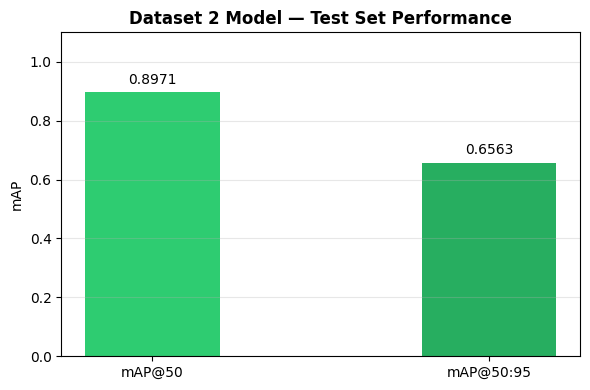

mAP@50=0.8971  mAP@50:95=0.6563


In [63]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 23: mAP summary bar chart
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 4))
metrics_vals = [test_metrics2['mAP@50'], test_metrics2['mAP@50:95']]
bars = ax.bar(['mAP@50', 'mAP@50:95'], metrics_vals, color=['#2ecc71', '#27ae60'], width=0.4)
ax.bar_label(bars, fmt='%.4f', padding=4)
ax.set_ylim(0, 1.1); ax.set_ylabel('mAP')
ax.set_title('Dataset 2 Model — Test Set Performance', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/plots/map_summary.png", dpi=120)
plt.show()
print(f'mAP@50={test_metrics2["mAP@50"]:.4f}  mAP@50:95={test_metrics2["mAP@50:95"]:.4f}')


## 11. Test-Time Augmentation (TTA)

In [64]:
from ensemble_boxes import weighted_boxes_fusion
# ─────────────────────────────────────────────────────────────────────────────
# Cell 25: Multi-scale Test-Time Augmentation (TTA) predictor
# Fuses: original + horizontal flip + multiple scales via WBF
# ─────────────────────────────────────────────────────────────────────────────
def apply_wbf(predictions, image_size=1024, iou_thr=0.4, skip_box_thr=0.05):
    boxes_list, scores_list, labels_list = [], [], []
    
    for pred in predictions:
        boxes_list.append((pred['boxes'].cpu().numpy() / image_size).tolist())
        scores_list.append(pred['scores'].cpu().numpy().tolist())
        labels_list.append(pred['labels'].cpu().numpy().tolist())
    
    boxes, scores, labels = weighted_boxes_fusion(
        boxes_list, scores_list, labels_list, weights=None, 
        iou_thr=iou_thr, skip_box_thr=skip_box_thr
    )
    
    return {
        'boxes': torch.tensor(boxes * image_size, dtype=torch.float32).to(DEVICE),
        'scores': torch.tensor(scores, dtype=torch.float32).to(DEVICE),
        'labels': torch.tensor(labels, dtype=torch.int64).to(DEVICE)
    }
    
class TTAPredictor:
    """
    Multi-scale + flip TTA for a single model.
    Augmentations applied:
      • original image at each scale
      • horizontally flipped image at each scale
    All predictions fused with WBF.
    """
    def __init__(self, model: nn.Module, class_map: Dict[int, int],
                 scales: List[float] = None, iou_thr: float = 0.5):
        self.model     = model.eval()
        self.class_map = class_map
        self.scales    = scales or CFG.get('tta_scales', [0.8, 1.0, 1.2])
        self.iou_thr   = iou_thr

    @torch.no_grad()
    def _run(self, img_tensor: torch.Tensor, min_score: float = 0.05):
        """Run model on one image tensor, return norm boxes/scores/labels."""
        h, w = img_tensor.shape[1], img_tensor.shape[2]
        out = self.model([img_tensor.to(DEVICE)])[0]
        mask   = out['scores'] >= min_score
        boxes  = out['boxes'][mask].cpu().numpy()
        scores = out['scores'][mask].cpu().numpy().tolist()
        labels = [self.class_map.get(int(l), 0)
                  for l in out['labels'][mask].cpu().numpy()]
        if len(boxes):
            boxes[:, [0, 2]] /= w; boxes[:, [1, 3]] /= h
            boxes = np.clip(boxes, 0, 1)
        return boxes.tolist(), scores, labels

    @torch.no_grad()
    def predict(self, img_tensor: torch.Tensor, min_score: float = 0.05) -> dict:
        """Fuse TTA predictions for one image tensor."""
        h, w = img_tensor.shape[1], img_tensor.shape[2]
        mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
        std  = torch.tensor([0.229, 0.224, 0.225])[:, None, None]

        all_boxes, all_scores, all_labels = [], [], []

        for scale in self.scales:
            # Rescale tensor (undo normalize → rescale → re-normalize)
            img_np = ((img_tensor * std + mean).permute(1, 2, 0)
                      .clamp(0, 1).numpy() * 255).astype(np.uint8)
            new_size = int(max(h, w) * scale)
            tfm = make_tta_transform(scale)

            for flip in [False, True]:
                aug_img = img_np[:, ::-1, :] if flip else img_np
                t = tfm(image=aug_img, bboxes=[], class_labels=[])
                aug_t = torch.from_numpy(
                    t['image'].transpose(2, 0, 1) if isinstance(t['image'], np.ndarray)
                    else np.array(t['image']).transpose(2, 0, 1)
                ).float() / 255.0
                # Already normalized by transform
                aug_t = torch.from_numpy(
                    t['image'] if isinstance(t['image'], np.ndarray) else np.array(t['image'])
                ).float()
                if aug_t.dim() == 3 and aug_t.shape[2] == 3:
                    aug_t = aug_t.permute(2, 0, 1)

                bh, bw = aug_t.shape[1], aug_t.shape[2]
                out = self.model([aug_t.to(DEVICE)])[0]
                mask   = out['scores'] >= min_score
                boxes  = out['boxes'][mask].cpu().numpy()
                scores = out['scores'][mask].cpu().numpy().tolist()
                labels = [self.class_map.get(int(l), 0)
                          for l in out['labels'][mask].cpu().numpy()]
                if len(boxes):
                    if flip:
                        boxes[:, [0, 2]] = bw - boxes[:, [2, 0]]
                    boxes[:, [0, 2]] /= bw; boxes[:, [1, 3]] /= bh
                    boxes = np.clip(boxes, 0, 1)
                all_boxes.append(boxes.tolist())
                all_scores.append(scores)
                all_labels.append(labels)

        fused_b, fused_s, fused_l = weighted_boxes_fusion(
            all_boxes, all_scores, all_labels, iou_thr=self.iou_thr)
        fused_px = np.array(fused_b)
        if len(fused_px):
            fused_px[:, [0, 2]] *= w; fused_px[:, [1, 3]] *= h

        return {
            'boxes':  torch.tensor(fused_px,  dtype=torch.float32),
            'scores': torch.tensor(fused_s,   dtype=torch.float32),
            'labels': torch.tensor(fused_l,   dtype=torch.int64),
        }


# Identity class map for DS2 (class ids match directly)
MAP2 = {i: i for i in range(NUM_CLASSES_DS2)}
tta2 = TTAPredictor(model2, MAP2, scales=CFG['tta_scales'])
print(f'✅ TTA predictor ready | scales={CFG["tta_scales"]} | '
      f'augmentations per image: {len(CFG["tta_scales"]) * 2} (orig + flip each scale)')

✅ TTA predictor ready | scales=[0.8, 1.0, 1.2] | augmentations per image: 6 (orig + flip each scale)


## 12. Model Saving & Export


In [65]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 26: Save model configuration & metadata
# ─────────────────────────────────────────────────────────────────────────────

model_cfg = {
    'model_path':    f"{CFG['output_dir']}/model_dataset2_best.pth",
    'num_classes':   NUM_CLASSES_DS2,
    'class_names':   CFG['classes_ds2'],
    'iou_threshold': CFG['iou_threshold'],
    'min_score':     CFG['min_score'],
    'test_metrics': {
        'mAP@50':    test_metrics2['mAP@50'],
        'mAP@50:95': test_metrics2['mAP@50:95'],
    },
}

cfg_path = f"{CFG['output_dir']}/model_config.json"
with open(cfg_path, 'w') as f:
    json.dump(model_cfg, f, indent=2)

print(f'✅ Model config saved to {cfg_path}')


✅ Model config saved to /kaggle/working/ds2_outputs/model_config.json


In [66]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 27: Convenience function to reload the trained model
# ─────────────────────────────────────────────────────────────────────────────

def load_model_from_config(config_path: str, device=None):
    """
    Load the saved model from its JSON config.
    Usage:
        model = load_model_from_config('output/model_config.json')
        out = model([image_tensor])
    """
    device = device or DEVICE
    with open(config_path) as f:
        cfg = json.load(f)
    ckpt  = torch.load(cfg['model_path'], map_location=device)
    model = build_faster_rcnn(cfg['num_classes'], DEFAULT_CONFIG)
    model.load_state_dict(ckpt['model'])
    model.to(device).eval()
    print(f'✅ Model loaded: {cfg["num_classes"]} classes, mAP@50={cfg["test_metrics"]["mAP@50"]:.4f}')
    return model


print('✅ load_model_from_config() ready.')
print('   Usage:  model = load_model_from_config("output/model_config.json")')


✅ load_model_from_config() ready.
   Usage:  model = load_model_from_config("output/model_config.json")


## 13. HTML Report Generation


In [67]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 28: Generate HTML summary report
# ─────────────────────────────────────────────────────────────────────────────

import base64

def img_to_b64(path: str) -> str:
    if not os.path.exists(path):
        return ''
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode()

def generate_html_report(output_dir: str, test_metrics: dict, history: dict):
    plots_dir = f'{output_dir}/plots'

    def embed_img(fname):
        b64 = img_to_b64(f'{plots_dir}/{fname}')
        if not b64:
            return '<p><em>Image not available</em></p>'
        return f'<img src="data:image/png;base64,{b64}" style="max-width:100%;border-radius:8px;"/>'

    pc_rows = ''.join(
        f'<tr><td>{CFG["classes_ds2"][int(k)] if int(k) < len(CFG["classes_ds2"]) else k}</td>'
        f'<td>{v:.4f}</td></tr>'
        for k, v in test_metrics.get('per_class_AP@50', {}).items()
    )

    html = f"""
<!DOCTYPE html><html><head>
<meta charset="UTF-8">
<title>Dental X-Ray Detection Report</title>
<style>
  body {{ font-family: Arial, sans-serif; max-width: 1000px; margin: auto; padding: 24px; background:#f9f9f9; }}
  h1 {{ color: #1a3a5c; }}\ h2 {{ color: #2c5f8a; border-bottom: 2px solid #2c5f8a; }}
  table {{ border-collapse: collapse; width: 100%; margin-bottom: 24px; }}
  th, td {{ border: 1px solid #ccc; padding: 8px 14px; text-align: left; }}
  th {{ background: #2c5f8a; color: white; }}
  tr:nth-child(even) {{ background: #eef4fb; }}
</style></head><body>
<h1>🦷 Dental X-Ray Object Detection — Report (Dataset 2)</h1>
<p>Generated: {time.strftime('%Y-%m-%d %H:%M:%S')}</p>

<h2>1. Dataset Summary</h2>
<table>
  <tr><th>Dataset</th><th>Train</th><th>Val</th><th>Test</th><th>Classes</th></tr>
  <tr><td>Dataset 2</td><td>{len(ds2_train)}</td><td>{len(ds2_val)}</td><td>{len(ds2_test)}</td>
      <td>{', '.join(CFG['classes_ds2'][1:])}</td></tr>
</table>

<h2>2. Class Distribution</h2>
{embed_img('class_distribution.png')}

<h2>2b. Anchor Box Optimization Analysis</h2>
{embed_img('anchor_optimizations.png')}

<h2>3. Training Curves</h2>
{embed_img('training_curves.png')}

<h2>4. Test Set Results</h2>
<table>
  <tr><th>Metric</th><th>Value</th></tr>
  <tr><td>mAP@50</td><td>{test_metrics['mAP@50']:.4f}</td></tr>
  <tr><td>mAP@50:95</td><td>{test_metrics['mAP@50:95']:.4f}</td></tr>
  <tr><td>Best val mAP@50</td><td>{max(history["val_map50"]):.4f}</td></tr>
  <tr><td>Total epochs</td><td>{len(history['train_loss'])}</td></tr>
</table>

<h2>5. Per-Class AP@50</h2>
<table><tr><th>Class</th><th>AP@50</th></tr>{pc_rows}</table>
{embed_img('per_class_ap.png')}

<h2>6. Sample Predictions</h2>
{embed_img('predictions.png')}

<h2>7. F1–Confidence Curve</h2>
{embed_img('f1_confidence.png')}

<h2>8. Precision/Recall/mAP Combined</h2>
{embed_img('precision_recall_map_combined.png')}

<h2>9. Loss Curves</h2>
{embed_img('loss_curves.png')}

<h2>10. Confusion Matrix</h2>
{embed_img('confusion_matrix.png')}

<h2>11. Class Balance Before vs After Augmentation</h2>
{embed_img('class_balance_before_after.png')}

<h2>12. GT vs Prediction Comparison</h2>
{embed_img('predictions_gt_vs_pred.png')}

<hr/><p style="color:gray;">Dental X-Ray Faster R-CNN · Dataset 2</p>
</body></html>
"""

    report_path = f'{output_dir}/report.html'
    with open(report_path, 'w') as f:
        f.write(html)
    print(f'✅ HTML report saved → {report_path}')

generate_html_report(CFG['output_dir'], test_metrics2, history2)


✅ HTML report saved → /kaggle/working/ds2_outputs/report.html


## 14. Final Summary & Results


## 15. 🚀 Tuning Guide — Squeeze More mAP

| What to change | Where | Expected gain |
|---|---|---|
| Increase `image_size` to 1280 | Config | +1–3 mAP (more detail for small caries) |
| Switch `backbone` to `resnet101` | Config | +1–2 mAP (deeper features) |
| Increase `num_epochs` to 200 | Config | +1–3 mAP (more training) |
| Lower `lr` to `2e-4` | Config | Helps on small datasets |
| Set `trainable_backbone_layers: 4` | Config | Allows deeper fine-tuning |
| Increase `tta_scales` to `[0.7, 0.85, 1.0, 1.15, 1.3]` | Config | +1–2 mAP at inference |
| Add more training data or augment with copy-paste | Dataset | Biggest possible gain |


In [68]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 30: Final summary
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd

df_summary = pd.DataFrame([{
    'Model': 'Dataset2 Faster R-CNN',
    'mAP@50': test_metrics2['mAP@50'],
    'mAP@50:95': test_metrics2['mAP@50:95'],
    'Best val mAP@50': max(history2['val_map50']),
    'Total epochs': len(history2['train_loss']),
}]).set_index('Model')

print('\n' + '='*65)
print('  🦷 DENTAL X-RAY DETECTION — FINAL RESULTS (Dataset 2)')
print('='*65)
print(df_summary.to_string())
print('='*65)

df_summary.to_csv(f"{CFG['output_dir']}/final_summary.csv")
print(f"\n💾 Summary saved to {CFG['output_dir']}/final_summary.csv")



  🦷 DENTAL X-RAY DETECTION — FINAL RESULTS (Dataset 2)
                         mAP@50  mAP@50:95  Best val mAP@50  Total epochs
Model                                                                    
Dataset2 Faster R-CNN  0.897054   0.656308         0.997387            30

💾 Summary saved to /kaggle/working/ds2_outputs/final_summary.csv


In [69]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 29: Quick outputs reference
# ─────────────────────────────────────────────────────────────────────────────

print('\n' + '='*65)
print('  🦷 DENTAL X-RAY DETECTION — OUTPUTS')
print('='*65)
print(f'  Test mAP@50    = {test_metrics2["mAP@50"]:.4f}')
print(f'  Test mAP@50:95 = {test_metrics2["mAP@50:95"]:.4f}')
print('='*65)
print(f'\n📁 Outputs saved in: {CFG["output_dir"]}/')
print('   model_dataset2_best.pth')
print('   model_config.json')
print('   test_metrics.csv')
print('   final_summary.csv')
print('   report.html')
print('   plots/')
print('\nTo reload the model later:')
print('   model = load_model_from_config("output/model_config.json")')
print('   out = model([image_tensor])')



  🦷 DENTAL X-RAY DETECTION — OUTPUTS
  Test mAP@50    = 0.8971
  Test mAP@50:95 = 0.6563

📁 Outputs saved in: /kaggle/working/ds2_outputs/
   model_dataset2_best.pth
   model_config.json
   test_metrics.csv
   final_summary.csv
   report.html
   plots/

To reload the model later:
   model = load_model_from_config("output/model_config.json")
   out = model([image_tensor])


In [74]:
!pip install -q google-api-python-client google-auth google-auth-httplib2

import json, os, zipfile
from tqdm.auto import tqdm
from google.oauth2.credentials import Credentials
from google.auth.transport.requests import Request
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload

# ── Step 1: Load credentials from the dataset ────────────────────────────────
CRED_PATH = '/kaggle/input/datasets/yousseforabi/kaggle-output-downloader/gdrive.json'

with open(CRED_PATH, 'r') as f:
    cred_data = json.load(f)['default']

creds = Credentials(
    token         = cred_data['access_token'],
    refresh_token = cred_data['refresh_token'],
    token_uri     = cred_data['token_uri'],
    client_id     = cred_data['client_id'],
    client_secret = cred_data['client_secret'],
    scopes        = cred_data['scopes'],
)

# ── Step 2: Force refresh (access token is expired) ──────────────────────────
creds.refresh(Request())
print('✅ Token refreshed successfully')

# ── Step 3: Build Drive service ───────────────────────────────────────────────
service = build('drive', 'v3', credentials=creds)
print('✅ Drive service ready')

# ── Step 4: Zip ds2_outputs ───────────────────────────────────────────────────
folder_path = CFG['output_dir']          # /kaggle/working/ds2_outputs
zip_path    = '/kaggle/working/ds2_outputs.zip'

all_files = []
for root, dirs, files in os.walk(folder_path):
    for file in files:
        all_files.append(os.path.join(root, file))

print(f'📁 Found {len(all_files)} files to zip')

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for file_path in tqdm(all_files, desc='📦 Zipping'):
        arcname = os.path.relpath(file_path, '/kaggle/working')
        zf.write(file_path, arcname)

zip_size = os.path.getsize(zip_path) / 1024**2
print(f'✅ Zip ready — {zip_size:.1f} MB')

# ── Step 5: Upload to Google Drive ───────────────────────────────────────────
FOLDER_ID  = '18qN6Yp8IUfq64oA7qCe0QXMdz2SoR8SB'
chunk_size = 5 * 1024 * 1024

media    = MediaFileUpload(zip_path, mimetype='application/zip',
                           chunksize=chunk_size, resumable=True)
metadata = {'name': 'ds2_outputs.zip', 'parents': [FOLDER_ID]}
request  = service.files().create(body=metadata, media_body=media, fields='id')

file_size = os.path.getsize(zip_path)
with tqdm(total=file_size, desc='🚀 Uploading', unit='B',
          unit_scale=True, unit_divisor=1024) as pbar:
    response = None
    prev     = 0
    while response is None:
        status, response = request.next_chunk()
        if status:
            pbar.update(int(status.resumable_progress) - prev)
            prev = int(status.resumable_progress)
    pbar.n = file_size
    pbar.refresh()

file_id = response.get('id')
print(f'✅ Uploaded → ds2_outputs.zip')
print(f'🔗 https://drive.google.com/file/d/{file_id}/view')

✅ Token refreshed successfully
✅ Drive service ready
📁 Found 21 files to zip


📦 Zipping:   0%|          | 0/21 [00:00<?, ?it/s]

✅ Zip ready — 150.5 MB


🚀 Uploading:   0%|          | 0.00/150M [00:00<?, ?B/s]

✅ Uploaded → ds2_outputs.zip
🔗 https://drive.google.com/file/d/1sHPOw36XzxXvjj1lbJnz_49wF6YbwZD-/view
